
# Ver.5 Dynamic GLM-HMM — 著者実装での再フィット（VG1GC-66）

[notebooks/17](17_ver5_pre_implementation_checks.ipynb) の Dynamic GLM-HMM は、held-out尤度が改善する一方で**状態が「セッション内の時計」に退化**していた。共有遷移行列が事実上の吸収行列になり、14 day すべてが同じ順序の3セグメント（前半・中盤・後半）に切られ、しかもそのうち1状態は History 回帰子の day 頭リセットが作る過渡に張り付いていた。

このノートは、その診断に対する2つの修正を **Cuturela et al. 2024 の公開実装** [lenca56/dynamic_glmhmm](https://github.com/lenca56/dynamic_glmhmm) を使って実行する。ノート17の自前実装は使わない。

| # | 修正 | 何を確かめるか |
| :--- | :--- | :--- |
| 1 | History 回帰子の day 頭リセットを止め、定常値から始める | day 冒頭の決定論的な過渡が消えたとき、状態が1つそれに費やされる現象が無くなるか |
| 3 | 重みの変動幅 $\sigma$ を**列別**にする（論文の $\alpha_{k,d}$） | スカラー1個では $\sigma$ がグリッド上端に張り付いた。列別にしたとき内点最適が現れるか |

**このノートでやらないこと**: 状態数 $K$ の掃引（$K=3$ に固定）、$\kappa$ の掃引（ノート17で `'partial'` が `'dynamic'` を上回ったため `'partial'` を主対象とする）。

**論文実装を使う理由と、それによって変わる点**:

* 重みへの絶対的なL2罰則は `model_type='standard'` にしか入らない（`value_weight_loss_function` 516–535行）。`'partial'` は隣接セッションとの差分項のみで、セッション0には `prevW` が無いので絶対的なアンカーが一つも無い。これは論文のモデルそのものであり、自前実装の欠陥ではない。
* 遷移行列の事前分布は `priorDirP=[10,1]`（対角10・非対角1）。**非対角に +1 の擬似カウントが入る**ため、ノート17の自前実装で生じた「厳密に0の遷移確率＝吸収状態」は構造的に起こらない。
* 初期状態分布 $\pi$ は一様固定（`fit_init_states=False`）。公開実装はセッション数20未満での $\pi$ 推定を例外で禁止しており、本データは14 dayなのでこれに従う。
* cross-validation は著者の `split_data`（各セッションを10試行ブロックに切り、ブロック単位で5-foldに振る）をそのまま使う。

## 0. セットアップ

In [1]:
import sys, os
from pathlib import Path

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    drive.mount('/content/drive')
    repo_path = Path('/content/braidyn-bc')
    if not repo_path.exists():
        os.system('git clone https://github.com/nyaamikeneko/braidyn-bc.git /content/braidyn-bc')
    os.chdir(repo_path)
else:
    here = Path.cwd()
    repo_root = here if (here / 'config.py').exists() else here.parent
    os.chdir(repo_root)

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
print('cwd:', Path.cwd())

cwd: /mnt/c/Users/dmasu/braidyn-bc


In [2]:
# Cuturela et al. 2024 の公開実装。無ければクローンする（.gitignore 済みの external/ に置く）。
DYN_REPO = Path('external') / 'dynamic_glmhmm'
if not (DYN_REPO / 'code' / 'dynamic_glmhmm.py').exists():
    DYN_REPO.parent.mkdir(parents=True, exist_ok=True)
    os.system(f'git clone --depth 1 https://github.com/lenca56/dynamic_glmhmm {DYN_REPO}')
if str((DYN_REPO / 'code').resolve()) not in sys.path:
    sys.path.insert(0, str((DYN_REPO / 'code').resolve()))

import dynamic_glmhmm
from utils import reshapeSigma
from analysis_utils import split_data
print('dynamic_glmhmm:', dynamic_glmhmm.__file__)

dynamic_glmhmm: /mnt/c/Users/dmasu/braidyn-bc/external/dynamic_glmhmm/code/dynamic_glmhmm.py


In [3]:
import time, io as _io, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import src.glmhmm_ver4 as v4

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)

MOUSE_ID = 'VG1GC-66'
ALPHA_ACT = v4.ALPHA_ACT     # 0.65
ALPHA_REW = v4.ALPHA_REW     # 0.80
SOUND_TYPES = ['Success', 'Short Pull', 'No Reaction']
K, C = 3, 2                  # 状態数は固定（掃引しない）
P_THRESHOLD = 0.80           # 要件6.1節
BURN = 20                    # History の定常値を測る際に落とす day 冒頭の試行数

# --- 論文実装のハイパーパラメータ（fit_cluster_*.py に合わせる） ---
FOLDS, BLOCKS, CV_SEED = 5, 10, 1
SIGMA_GRID = [1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0, 1000.0]   # 論文は 10^-3 .. 10^3
STD_MAXITER, STD_TOL, L2_STD = 100, 1e-3, 1                 # 'standard' 段のみ L2 が効く
PAR_MAXITER, PAR_TOL = 25, 1e-3
PRIOR_DIR_P = [10, 1]                                       # 対角10・非対角1

CACHE_DIR = Path('data') / 'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_TRIALS = CACHE_DIR / f'ver5_trials_{MOUSE_ID}.pkl'
NB18_CACHE = CACHE_DIR / 'ver5_note18.pkl'

if CACHE_TRIALS.exists():
    trials_all = pd.read_pickle(CACHE_TRIALS)
    print('キャッシュから読み込み:', CACHE_TRIALS)
else:
    trials_all = v4.process_mouse(MOUSE_ID, alpha_act=ALPHA_ACT, alpha_rew=ALPHA_REW)['trials']
    trials_all.to_pickle(CACHE_TRIALS)
    print('キャッシュを作成:', CACHE_TRIALS)

NB18 = pd.read_pickle(NB18_CACHE) if NB18_CACHE.exists() else {}
print('note18 キャッシュ:', sorted(NB18) if NB18 else '(なし)')


def save_cache():
    pd.to_pickle(NB18, NB18_CACHE)


@contextlib.contextmanager
def quiet():
    '''著者実装は50反復ごとに反復数を print するので抑制する。'''
    buf = _io.StringIO()
    with contextlib.redirect_stdout(buf):
        yield

環境: ローカル (WSL)
DATA_CSV_ROOT: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data
DATA_CSV_BACKUP_ROOT: /mnt/g/マイドライブ/braidyn-bc-backup/hackathon_data


キャッシュから読み込み: data/cache/ver5_trials_VG1GC-66.pkl


note18 キャッシュ: ['final_fixed', 'final_reset', 'sigA_fixed', 'sigA_reset', 'sigB_fixed', 'std_fixed', 'std_reset']



## 1. 修正1 — History 回帰子の day 頭リセットを止める

ノート17（および Ver.4 の `add_history`）は指数フィルタを各 day の先頭で $h_0 = 0$ から始めている。マウスの押下率は 0.765 なので定常値は $0.765/(1-0.65) \approx 2.19$ であり、**0 から始めると day 冒頭に決定論的な立ち上がりが生じる**。z-score 化後は $k=0$ で $-2.5$ 前後という極端な値になり、これが14 day すべてで同じ形で繰り返される。

修正は、各 day の先頭を**全 day プールの定常値**から始めること。定常値は $h_0=0$ で作った系列の burn-in（先頭 `BURN` 試行）を除いた平均で測る（解析的な $\hat{p}/(1-\alpha)$ ともほぼ一致する）。

In [4]:
def build_sequence(trials_all, h0=0.0, r0=0.0):
    '''要件2.1節の音提示試行のみの系列を作り、その上で History を計算する。
    h0 / r0 は各 day 先頭でのフィルタ初期値（0 なら Ver.4・ノート17 と同じ挙動）。'''
    out = []
    for day, g in trials_all.groupby('task_day', sort=False):
        g = (g[g['trial_type'].isin(SOUND_TYPES)]
             .sort_values('t_start').reset_index(drop=True).copy())
        a = (g['trial_type'] != 'No Reaction').astype(int).to_numpy()
        rw = (g['trial_type'] == 'Success').astype(int).to_numpy()
        n = len(g)
        h = np.zeros(n); r = np.zeros(n)
        h[0], r[0] = h0, r0
        for k in range(1, n):
            h[k] = a[k - 1] + ALPHA_ACT * h[k - 1]
            r[k] = rw[k - 1] + ALPHA_REW * r[k - 1]
        g['x_bias'] = 1.0
        g['x_hist'] = h
        g['x_rew'] = r
        g['yA'] = 1 - a            # 1 = No Reaction（著者実装は参照クラス c=0）
        g['k'] = np.arange(n)
        out.append(g)
    tr = pd.concat(out, ignore_index=True)
    for c in ['x_hist', 'x_rew']:
        tr[c + '_z'] = (tr[c] - tr[c].mean()) / tr[c].std(ddof=0)
    return tr


INPUT_COLS = ['x_bias', 'x_hist_z', 'x_rew_z']

tr_reset = build_sequence(trials_all)                       # ノート17と同じ（day頭リセット）
H0 = float(tr_reset.loc[tr_reset['k'] >= BURN, 'x_hist'].mean())
R0 = float(tr_reset.loc[tr_reset['k'] >= BURN, 'x_rew'].mean())
tr_fixed = build_sequence(trials_all, H0, R0)               # 修正1

p_act = float((tr_reset['yA'] == 0).mean())
p_rew = float((tr_reset['trial_type'] == 'Success').mean())
print(f'burn-in({BURN}試行) 後の平均   h0={H0:.3f}  r0={R0:.3f}')
print(f'解析的な定常値 p/(1-alpha)  h0={p_act / (1 - ALPHA_ACT):.3f}  r0={p_rew / (1 - ALPHA_REW):.3f}')
print(f'音提示試行 {len(tr_reset)} 件 / {tr_reset["task_day"].nunique()} day')

burn-in(20試行) 後の平均   h0=2.166  r0=2.706
解析的な定常値 p/(1-alpha)  h0=2.185  r0=2.741
音提示試行 2359 件 / 14 day


In [5]:
head = pd.concat([
    tr_reset[tr_reset['k'] < 8].groupby('k')[['x_hist_z', 'x_rew_z']].mean()
        .add_suffix('  (reset: ノート17)'),
    tr_fixed[tr_fixed['k'] < 8].groupby('k')[['x_hist_z', 'x_rew_z']].mean()
        .add_suffix('  (fixed: 修正1)'),
], axis=1)
print('day 冒頭の入力（z-score済み、14 day平均）')
print(head.round(3).to_string())

for name, t in [('reset', tr_reset), ('fixed', tr_fixed)]:
    d = (t.loc[t['k'] < 10, ['x_hist_z', 'x_rew_z']].mean()
         - t.loc[t['k'] >= 10, ['x_hist_z', 'x_rew_z']].mean())
    print(f'{name}: 冒頭10試行と以降の差  x_hist_z {d["x_hist_z"]:+.3f}  x_rew_z {d["x_rew_z"]:+.3f}')

day 冒頭の入力（z-score済み、14 day平均）
   x_hist_z  (reset: ノート17)  x_rew_z  (reset: ノート17)  x_hist_z  (fixed: 修正1)  x_rew_z  (fixed: 修正1)
k                                                                                                  
0                    -2.494                   -2.010                  -0.019                 -0.018
1                    -1.415                   -1.522                   0.185                  0.061
2                    -0.879                   -1.186                   0.147                  0.069
3                    -0.530                   -0.809                   0.122                  0.187
4                    -0.304                   -0.670                   0.106                  0.113
5                    -0.074                   -0.450                   0.181                  0.167
6                    -0.007                   -0.383                   0.144                  0.097
7                     0.202                   -0.166                  

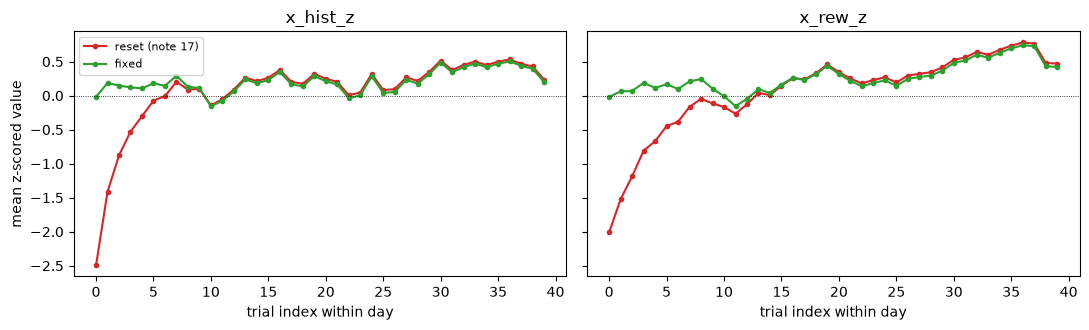

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, col in zip(axes, ['x_hist_z', 'x_rew_z']):
    for name, t, c in [('reset (note 17)', tr_reset, '#d62728'), ('fixed', tr_fixed, '#2ca02c')]:
        m = t[t['k'] < 40].groupby('k')[col].mean()
        ax.plot(m.index, m.values, marker='o', ms=3, color=c, label=name)
    ax.axhline(0, color='k', lw=.6, ls=':')
    ax.set_xlabel('trial index within day'); ax.set_title(col)
axes[0].set_ylabel('mean z-scored value'); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 2. 論文実装に渡す形にする

公開実装は配列を**セッション単位ではなくデータ点単位**で持つ（重み `initW` は `N x K x D x C`、遷移行列 `initP` は `N x K x K`）。セッション境界は `sessInd`（各セッションの開始index＋末尾+1）で伝える。観測 `y` と欠測マスク `present` は1次元。参照クラスは `c=0` で、重みは `w[:,:,:,1]` に入る。

In [7]:
def make_arrays(tr):
    days = list(dict.fromkeys(tr['task_day'].tolist()))
    x = tr[INPUT_COLS].to_numpy(dtype=float)
    y = tr['yA'].to_numpy().astype(int)
    sessInd = [0] + list(np.cumsum([int((tr['task_day'] == d).sum()) for d in days]))
    return x, y, sessInd, days


X_FIX, Y_FIX, SESS, DAYS = make_arrays(tr_fixed)
X_RES, Y_RES, SESS_R, _ = make_arrays(tr_reset)
assert SESS == SESS_R and (Y_FIX == Y_RES).all()   # 系列と観測は同一、入力だけが違う
N, D = X_FIX.shape

presentTrain, presentTest = split_data(N, SESS, folds=FOLDS, blocks=BLOCKS, random_state=CV_SEED)
print(f'N={N}  D={D}  sessions={len(SESS) - 1}  K={K}')
print('day別試行数:', [SESS[i + 1] - SESS[i] for i in range(len(SESS) - 1)])
print('foldごとのtest試行数:', [int(pt.sum()) for pt in presentTest])
print('y の内訳 (0=押下あり, 1=No Reaction):', np.bincount(Y_FIX))

N=2359  D=3  sessions=14  K=3
day別試行数: [np.int64(76), np.int64(156), np.int64(103), np.int64(183), np.int64(318), np.int64(157), np.int64(153), np.int64(72), np.int64(155), np.int64(233), np.int64(233), np.int64(126), np.int64(231), np.int64(163)]
foldごとのtest試行数: [548, 510, 479, 402, 420]
y の内訳 (0=押下あり, 1=No Reaction): [1804  555]


In [8]:
def init_params(seed=0):
    rng = np.random.default_rng(seed)
    initW = np.zeros((N, K, D, C))
    initW[:, :, :, 1] = rng.normal(0, 0.5, (K, D))
    initP = np.full((N, K, K), 0.2 / (K - 1))
    for i in range(K):
        initP[:, i, i] = 0.8
    return initW, initP, np.full(K, 1.0 / K)


def fit_standard(x, y, present, seed=0):
    '''`standard` 段（重み・遷移行列とも全day共通）。ここだけ L2penaltyW が効く。'''
    m = dynamic_glmhmm.dynamic_GLMHMM(N, K, D, C)
    initW, initP, initpi = init_params(seed)
    with quiet():
        p, pi, w, ll = m.fit(x, y, present, initP, initpi, initW,
                             sigma=reshapeSigma(0.0, K, D), sessInd=SESS,
                             maxIter=STD_MAXITER, tol=STD_TOL, L2penaltyW=L2_STD,
                             priorDirP=PRIOR_DIR_P, model_type='standard',
                             fit_init_states=False)
    return m, p, pi, w, float(ll[ll != 0][-1])


def fit_partial(m, x, y, present, sigma, p0, pi0, w0):
    '''`partial` 段（重みはday別、遷移行列は全day共通）。sigma はスカラーか (1, D) 配列。'''
    with quiet():
        p, pi, w, ll = m.fit(x, y, present, p0, pi0, w0,
                             sigma=reshapeSigma(sigma, K, D), sessInd=SESS,
                             maxIter=PAR_MAXITER, tol=PAR_TOL, L2penaltyW=0,
                             priorDirP=PRIOR_DIR_P, model_type='partial',
                             fit_init_states=False)
    return p, pi, w, float(ll[ll != 0][-1])


## 3. $\sigma$ の cross-validation

論文と同じ手順で、fold ごとに `'standard'` を学習してから $\sigma$ を昇順に歩き、各 $\sigma$ のフィットを次の $\sigma$ の初期値にする（`fit_eval_CV_partial_model` と同じ温スタート）。$\sigma=0$ に相当するのが `'standard'` そのもの。

修正1の効果を切り分けるため、**同じ手順を `reset`（ノート17の入力）と `fixed`（修正1後の入力）の両方に適用する**。系列・観測・fold分割はすべて共通で、違うのは入力の day 冒頭だけ。

In [9]:
def cv_sigma_scalar(x, y, tag, sigma_list=SIGMA_GRID):
    '''fold ごとに standard → sigma 昇順の partial。戻り値は (standard の test LL, sigma別 test LL)。'''
    key_std, key_sig = f'std_{tag}', f'sigA_{tag}'
    if key_sig in NB18:
        print(f'[cache] {tag}')
        return NB18[key_std]['ll_test'], NB18[key_sig]

    ll_std = np.zeros(FOLDS)
    ll_sig = np.zeros((len(sigma_list), FOLDS))
    std_fits = []
    t0 = time.time()
    for f in range(FOLDS):
        m, p, pi, w, ll_tr = fit_standard(x, y, presentTrain[f])
        _, ll_std[f], _ = m.evaluate(x, y, SESS, presentTest[f], p, pi, w)
        std_fits.append((p, pi, w))
        for i, s in enumerate(sigma_list):
            p, pi, w, _ = fit_partial(m, x, y, presentTrain[f], float(s), p, pi, w)
            _, ll_sig[i, f], _ = m.evaluate(x, y, SESS, presentTest[f], p, pi, w)
        print(f'  [{tag}] fold {f}: standard {ll_std[f]:+.4f} | '
              + ' '.join(f'{v:+.4f}' for v in ll_sig[:, f]) + f'  ({time.time() - t0:.0f}s)')
    NB18[key_std] = dict(ll_test=ll_std, fits=std_fits)
    NB18[key_sig] = ll_sig
    save_cache()
    return ll_std, ll_sig


ll_std_fix, ll_sig_fix = cv_sigma_scalar(X_FIX, Y_FIX, 'fixed')
ll_std_res, ll_sig_res = cv_sigma_scalar(X_RES, Y_RES, 'reset')

[cache] fixed
[cache] reset


In [10]:
def cv_table(ll_std, ll_sig, sigma_list=SIGMA_GRID):
    rows = [{'sigma': 0.0, 'model': 'standard',
             'test_ll': ll_std.mean(), 'se': ll_std.std(ddof=0) / np.sqrt(FOLDS)}]
    for i, s in enumerate(sigma_list):
        rows.append({'sigma': s, 'model': 'partial',
                     'test_ll': ll_sig[i].mean(),
                     'se': ll_sig[i].std(ddof=0) / np.sqrt(FOLDS)})
    return pd.DataFrame(rows)


cv_fix, cv_res = cv_table(ll_std_fix, ll_sig_fix), cv_table(ll_std_res, ll_sig_res)
for name, t in [('fixed（修正1あり）', cv_fix), ('reset（ノート17と同じ入力）', cv_res)]:
    best = t.loc[t['test_ll'].idxmax()]
    print(f'--- {name} ---')
    print(t.round(4).to_string(index=False))
    print(f'  最良: sigma={best["sigma"]:g} ({best["model"]}), test LL/試行 {best["test_ll"]:+.4f}')
    edge = (best['sigma'] == SIGMA_GRID[-1])
    print(f'  グリッド上端に張り付いたか: {"YES" if edge else "no"}\n')

# 列別sigmaの出発点は partial 行の最良値（standard が全体最良でも sigma=0 は partial に渡せない）
_par = cv_fix[cv_fix['model'] == 'partial']
SIGMA_BEST = float(_par.loc[_par['test_ll'].idxmax(), 'sigma'])
print(f'以降で使うスカラー sigma = {SIGMA_BEST:g}')

--- fixed（修正1あり） ---
   sigma    model  test_ll     se
   0.000 standard  -0.4258 0.0066
   0.001  partial  -0.4251 0.0064
   0.010  partial  -0.4249 0.0064
   0.100  partial  -0.4213 0.0063
   1.000  partial  -0.4201 0.0059
  10.000  partial  -0.4420 0.0077
 100.000  partial  -0.4638 0.0122
1000.000  partial  -0.4992 0.0233
  最良: sigma=1 (partial), test LL/試行 -0.4201
  グリッド上端に張り付いたか: no

--- reset（ノート17と同じ入力） ---
   sigma    model  test_ll     se
   0.000 standard  -0.4350 0.0069
   0.001  partial  -0.4348 0.0069
   0.010  partial  -0.4346 0.0069
   0.100  partial  -0.4289 0.0070
   1.000  partial  -0.4225 0.0086
  10.000  partial  -0.4439 0.0072
 100.000  partial  -0.4830 0.0243
1000.000  partial  -0.5787 0.1025
  最良: sigma=1 (partial), test LL/試行 -0.4225
  グリッド上端に張り付いたか: no

以降で使うスカラー sigma = 1


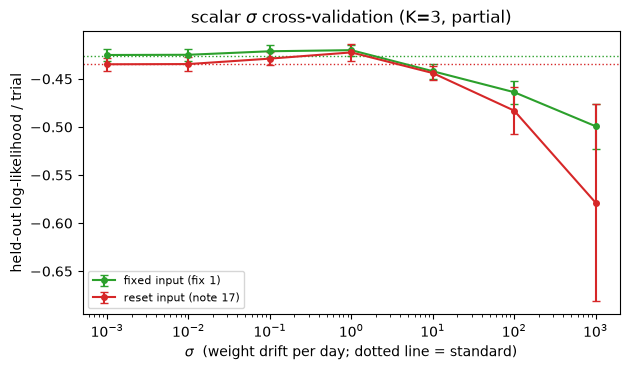

In [11]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
for t, name, c in [(cv_fix, 'fixed input (fix 1)', '#2ca02c'), (cv_res, 'reset input (note 17)', '#d62728')]:
    sub = t[t['model'] == 'partial']
    ax.errorbar(sub['sigma'], sub['test_ll'], yerr=sub['se'], marker='o', ms=4,
                color=c, capsize=3, label=name)
    std = t[t['model'] == 'standard'].iloc[0]
    ax.axhline(std['test_ll'], color=c, ls=':', lw=1)
ax.set_xscale('log')
ax.set_xlabel(r'$\sigma$  (weight drift per day; dotted line = standard)')
ax.set_ylabel('held-out log-likelihood / trial')
ax.set_title(r'scalar $\sigma$ cross-validation (K=3, partial)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### 3.2 修正3 — 列別 $\sigma$

論文の定式化は $lpha_{k,d}$（状態 $k$・入力次元 $d$ ごと）で、公開実装の `sigma` は `K x D` 配列を受ける。ここでは Bias 列と History 2列を分けた2次元版（著者の `fit_eval_CV_2Dsigmas` と同じ発想）を、スカラー最良値のまわりで座標降下的に探索する。

**この掃引は Bias 座標だけで打ち切っている。** 理由は2つ。(1) 3.1節の $\sigma$ 曲線が両方の入力で $\sigma>1$ から単調に悪化しており、大きい $\sigma$ は重みが無拘束になって L-BFGS の反復が急増する（$\sigma=100$ の1点で約48分かかる）。(2) 下に示すとおり Bias 座標の掃引幅が 0.0005 nats/試行しかなく、fold間のSE（約0.006）より1桁小さい。**この個体では列別 $\sigma$ に測定できる利得が無い**ので、以降の最終フィットはスカラー $\sigma$ を使う。History 座標を回すのは、他個体で Bias 座標に有意な差が出た場合でよい。

$\sigma_{bias}$ の掃引は $\sigma_{hist}$ を3.1節の最良値に固定し、$10^{-3}$–$10^{2}$ の6点で行う（$\sigma=10^{3}$ は最適から遠く、argmax に影響しないので外す）。

In [12]:
SIGMA_GRID_2D = SIGMA_GRID[:-1]      # sigma=1000 は外す（上の理由による）


def cv_sigma_bias(x, y, tag, sigma_list=SIGMA_GRID_2D):
    '''sigma = [sigma_bias, sigma_hist, sigma_hist] の bias 座標だけを掃引する。'''
    key = f'sigB_{tag}'
    if key in NB18:
        print(f'[cache] {key}')
        return NB18[key]

    std_fits = NB18[f'std_{tag}']['fits']
    m = dynamic_glmhmm.dynamic_GLMHMM(N, K, D, C)
    rows = []
    t0 = time.time()
    for s in sigma_list:
        vec = np.array([[float(s), SIGMA_BEST, SIGMA_BEST]])
        lls = np.zeros(FOLDS)
        for f in range(FOLDS):
            p, pi, w = std_fits[f]
            p, pi, w, _ = fit_partial(m, x, y, presentTrain[f], vec, p, pi, w)
            _, lls[f], _ = m.evaluate(x, y, SESS, presentTest[f], p, pi, w)
        rows.append({'coord': 'bias', 'sigma_bias': float(vec[0, 0]),
                     'sigma_hist': float(vec[0, 1]), 'test_ll': float(lls.mean()),
                     'se': float(lls.std(ddof=0) / np.sqrt(FOLDS))})
        print(f'  [bias] sigma={s:<8g} test LL {lls.mean():+.4f}  ({time.time() - t0:.0f}s)')
    tbl = pd.DataFrame(rows)
    out = dict(table=tbl, sigma_bias=float(tbl.loc[tbl['test_ll'].idxmax(), 'sigma_bias']),
               sigma_hist=SIGMA_BEST, partial=True, sigma_grid=list(sigma_list))
    NB18[key] = out
    save_cache()
    return out


sig2d = cv_sigma_bias(X_FIX, Y_FIX, 'fixed')
print()
print(sig2d['table'].round(4).to_string(index=False))
spread = sig2d['table']['test_ll'].max() - sig2d['table']['test_ll'].min()
print()
print(f'bias 座標の最良 sigma_bias={sig2d["sigma_bias"]:g} '
      f'(sigma_hist={sig2d["sigma_hist"]:g} 固定)')
print(f'  掃引幅 {spread:.4f} nats/試行  vs  fold間SE {sig2d["table"]["se"].mean():.4f}')
print(f'  スカラー最良 {cv_fix["test_ll"].max():+.4f} → 列別最良 '
      f'{sig2d["table"]["test_ll"].max():+.4f} '
      f'({sig2d["table"]["test_ll"].max() - cv_fix["test_ll"].max():+.4f} nats/試行)')

# 列別にする利得が SE 以下なので、最終フィットはスカラー sigma を使う
SIGMA_FINAL = SIGMA_BEST
print()
print(f'最終フィットで使う sigma = {SIGMA_FINAL:g}（全列共通）')

[cache] sigB_fixed

coord  sigma_bias  sigma_hist  test_ll     se
 bias       0.001         1.0  -0.4218 0.0064
 bias       0.010         1.0  -0.4218 0.0063
 bias       0.100         1.0  -0.4216 0.0061
 bias       1.000         1.0  -0.4221 0.0061
 bias      10.000         1.0  -0.4263 0.0049
 bias     100.000         1.0  -0.4273 0.0051

bias 座標の最良 sigma_bias=0.1 (sigma_hist=1 固定)
  掃引幅 0.0058 nats/試行  vs  fold間SE 0.0058
  スカラー最良 -0.4201 → 列別最良 -0.4216 (-0.0015 nats/試行)

最終フィットで使う sigma = 1（全列共通）



## 4. 最終フィットと状態構造

選ばれた $\sigma$ で全試行を使って学習し直し（欠測マスク無し）、ノート17と同じ指標で状態構造を見る。比較のため `reset` 側も同じ $\sigma$ で学習する。

In [13]:
def final_fit(x, y, sigma, tag):
    key = f'final_{tag}'
    if key in NB18:
        print(f'[cache] {key}')
        return NB18[key]
    present = np.ones(N)
    m, p0, pi0, w0, ll_tr = fit_standard(x, y, present)
    p, pi, w, ll_par = fit_partial(m, x, y, present, sigma, p0, pi0, w0)
    out = dict(std=(p0, pi0, w0), par=(p, pi, w), ll_std=ll_tr, ll_par=ll_par)
    NB18[key] = out
    save_cache()
    return out


fin_fix = final_fit(X_FIX, Y_FIX, SIGMA_FINAL, 'fixed')
fin_res = final_fit(X_RES, Y_RES, SIGMA_FINAL, 'reset')
print(f'fixed: standard train LL {fin_fix["ll_std"]:.2f} / partial {fin_fix["ll_par"]:.2f}')
print(f'reset: standard train LL {fin_res["ll_std"]:.2f} / partial {fin_res["ll_par"]:.2f}')

[cache] final_fixed
[cache] final_reset
fixed: standard train LL -992.14 / partial -947.22
reset: standard train LL -1008.20 / partial -943.43


In [14]:
def decode(x, y, fit_key):
    p, pi, w = fit_key
    m = dynamic_glmhmm.dynamic_GLMHMM(N, K, D, C)
    with quiet():
        gamma = m.posterior_likelihood_of_each_state(p, pi, w, x, y, np.ones(N), SESS)
    return gamma, gamma.argmax(axis=1), gamma.max(axis=1)


def state_summary(x, y, fit, label, verbose=True):
    gamma, z, pmax = decode(x, y, fit)
    occ = np.zeros((len(DAYS), K)); switches = []; runs = []; pos_by_state = [[] for _ in range(K)]
    for i in range(len(DAYS)):
        sl = slice(SESS[i], SESS[i + 1])
        zi = z[sl]
        for k in range(K):
            occ[i, k] = (zi == k).mean()
        switches.append(int((np.diff(zi) != 0).sum()))
        cut = np.flatnonzero(np.diff(zi) != 0) + 1
        runs += [len(s) for s in np.split(zi, cut)]
        rel = np.linspace(0, 1, len(zi))
        for k in range(K):
            pos_by_state[k].append(rel[zi == k])
    dom = occ.max(axis=1)
    p_mat = fit[0][0]
    if verbose:
        print(f'[{label}]')
        print(f'  1状態が90%以上のday: {int((dom >= 0.9).sum())}/{len(DAYS)}'
              f'  (最頻状態占有率の中央値 {np.median(dom):.3f})')
        print(f'  day内の状態切り替え: 合計 {sum(switches)} 回 / day中央値 {int(np.median(switches))}'
              f'  / day別 {switches}')
        print(f'  state run長: 中央値 {int(np.median(runs))} 試行 / 最大 {max(runs)}')
        print(f'  p_max 平均 {pmax.mean():.3f} / P(z)>={P_THRESHOLD} 残存率 {(pmax >= P_THRESHOLD).mean():.3f}')
        print('  共有遷移行列 P:')
        print('   ', np.array2string(np.round(p_mat, 4), prefix='    '))
        print(f'    行和 {np.round(p_mat.sum(axis=1), 5)}  ← 著者実装のDirichlet更新は厳密には正規化されない')
        print('  day内の正規化位置（状態別 平均±sd）:')
        for k in range(K):
            v = np.concatenate(pos_by_state[k])
            desc = f'{v.mean():.3f} +- {v.std():.3f}' if v.size else 'n/a'
            print(f'    state {k}: n={int((z == k).sum()):4d}  pos {desc}')
        wmax = np.abs(fit[2][:, :, :, 1]).max()
        print(f'  |W| の最大 {wmax:.1f} / |W|>5 の割合 {(np.abs(fit[2][:, :, :, 1]) > 5).mean():.3f}')
        print()
    return dict(gamma=gamma, z=z, pmax=pmax, occ=occ, switches=np.array(switches),
                runs=np.array(runs), dom=dom)


sm_std_fix = state_summary(X_FIX, Y_FIX, fin_fix['std'], 'fixed / standard')
sm_par_fix = state_summary(X_FIX, Y_FIX, fin_fix['par'], 'fixed / partial（修正1+3）')
sm_par_res = state_summary(X_RES, Y_RES, fin_res['par'], 'reset / partial（修正3のみ）')

[fixed / standard]
  1状態が90%以上のday: 6/14  (最頻状態占有率の中央値 0.867)
  day内の状態切り替え: 合計 44 回 / day中央値 2  / day別 [1, 6, 0, 0, 2, 0, 4, 3, 1, 0, 5, 4, 7, 11]
  state run長: 中央値 17 試行 / 最大 246
  p_max 平均 0.748 / P(z)>=0.8 残存率 0.479
  共有遷移行列 P:
    [[0.9487 0.0093 0.0412]
     [0.0045 0.9915 0.004 ]
     [0.0361 0.0117 0.9515]]
    行和 [0.99919 0.99994 0.99927]  ← 著者実装のDirichlet更新は厳密には正規化されない
  day内の正規化位置（状態別 平均±sd）:
    state 0: n= 534  pos 0.540 +- 0.294
    state 1: n=1321  pos 0.493 +- 0.283
    state 2: n= 504  pos 0.477 +- 0.301
  |W| の最大 1.8 / |W|>5 の割合 0.000

[fixed / partial（修正1+3）]
  1状態が90%以上のday: 6/14  (最頻状態占有率の中央値 0.761)
  day内の状態切り替え: 合計 29 回 / day中央値 1  / day別 [4, 1, 0, 1, 1, 0, 3, 1, 1, 2, 6, 0, 6, 3]
  state run長: 中央値 32 試行 / 最大 245
  p_max 平均 0.714 / P(z)>=0.8 残存率 0.351
  共有遷移行列 P:
    [[0.9543 0.017  0.0281]
     [0.0072 0.9835 0.0092]
     [0.0391 0.042  0.9169]]
    行和 [0.99931 0.9999  0.99806]  ← 著者実装のDirichlet更新は厳密には正規化されない
  day内の正規化位置（状態別 平均±sd）:
    state 0: n= 453  pos 0.5

[reset / partial（修正3のみ）]
  1状態が90%以上のday: 11/14  (最頻状態占有率の中央値 0.942)
  day内の状態切り替え: 合計 35 回 / day中央値 2  / day別 [0, 1, 4, 7, 1, 1, 2, 1, 3, 3, 3, 0, 7, 2]
  state run長: 中央値 12 試行 / 最大 305
  p_max 平均 0.848 / P(z)>=0.8 残存率 0.747
  共有遷移行列 P:
    [[0.7335 0.145  0.107 ]
     [0.0116 0.9835 0.0048]
     [0.0458 0.0563 0.8948]]
    行和 [0.98549 0.99992 0.9969 ]  ← 著者実装のDirichlet更新は厳密には正規化されない
  day内の正規化位置（状態別 平均±sd）:
    state 0: n=  40  pos 0.536 +- 0.346
    state 1: n=2173  pos 0.519 +- 0.276
    state 2: n= 146  pos 0.204 +- 0.321
  |W| の最大 3.4 / |W|>5 の割合 0.000



In [15]:
occ = pd.DataFrame(sm_par_fix['occ'], index=DAYS,
                   columns=[f'state {k}' for k in range(K)])
occ['switches'] = sm_par_fix['switches']
print('fixed / partial の day別 状態占有率:')
print(occ.round(3).to_string())

fixed / partial の day別 状態占有率:
            state 0  state 1  state 2  switches
task-day1     0.158    0.737    0.105         4
task-day3     0.314    0.686    0.000         1
task-day4     0.000    1.000    0.000         0
task-day5     0.011    0.989    0.000         1
task-day6     0.230    0.770    0.000         1
task-day7     0.000    1.000    0.000         0
task-day8     0.752    0.229    0.020         3
task-day9     0.000    0.958    0.042         1
task-day10    0.252    0.748    0.000         1
task-day11    0.039    0.923    0.039         2
task-day12    0.197    0.571    0.232         6
task-day13    0.000    1.000    0.000         0
task-day14    0.364    0.602    0.035         6
task-day15    0.147    0.742    0.110         3



## 5. day ごとのパネル図

ノート16（`v4.plot_day_panel`）と同じ構成で、試行インデックスを共有軸にした1枚のパネルを day ごとに描く。**Stimulus 段は無い**——Ver.5 は系列を音提示試行に限ったため $x_{stim} \equiv 1$ で、[requirements_ver5.md](../docs/requirements_ver5.md) 4.2節で入力から落としている。

最下段は Viterbi 系列ではなく、試行ごとの周辺事後確率の最大値をとった **MAP 状態**（`argmax_k gamma_t(k)`）である。5.6節の切り替え回数・占有率もこの系列で数えている。

主対象は fixed 入力の `'partial'`（修正1+3）。比較用の reset 入力と `'standard'` は、全 day を1枚に収めた積み上げ図で並べる。

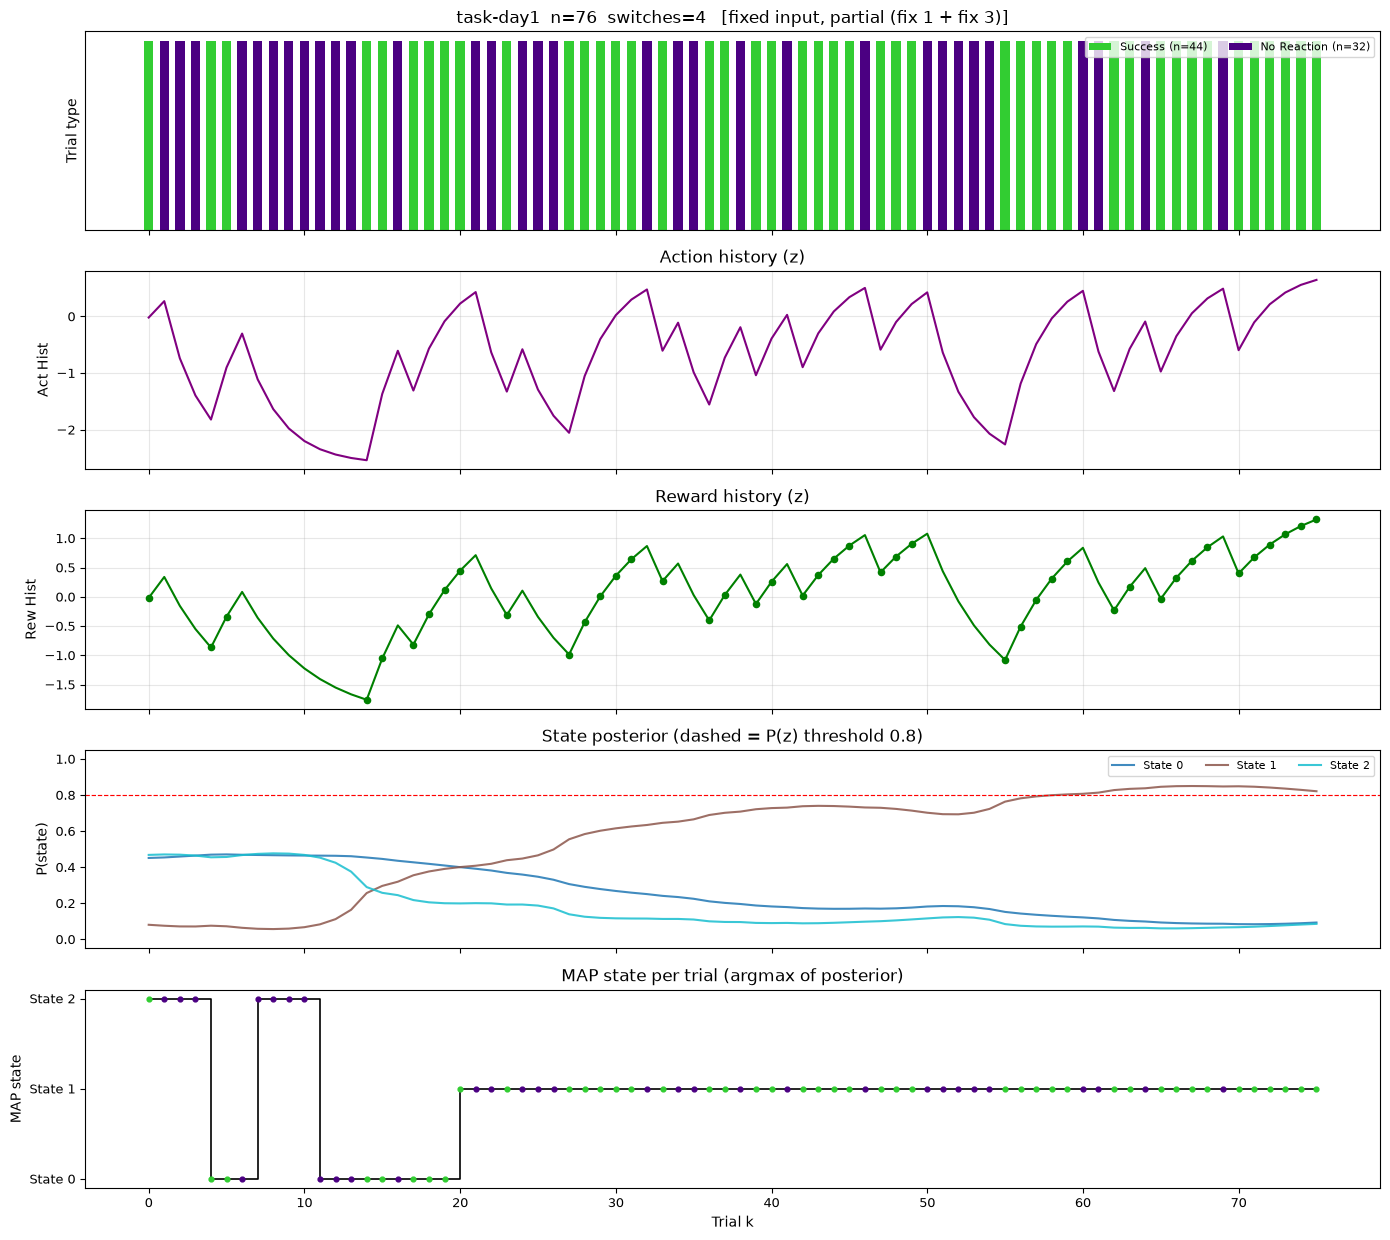

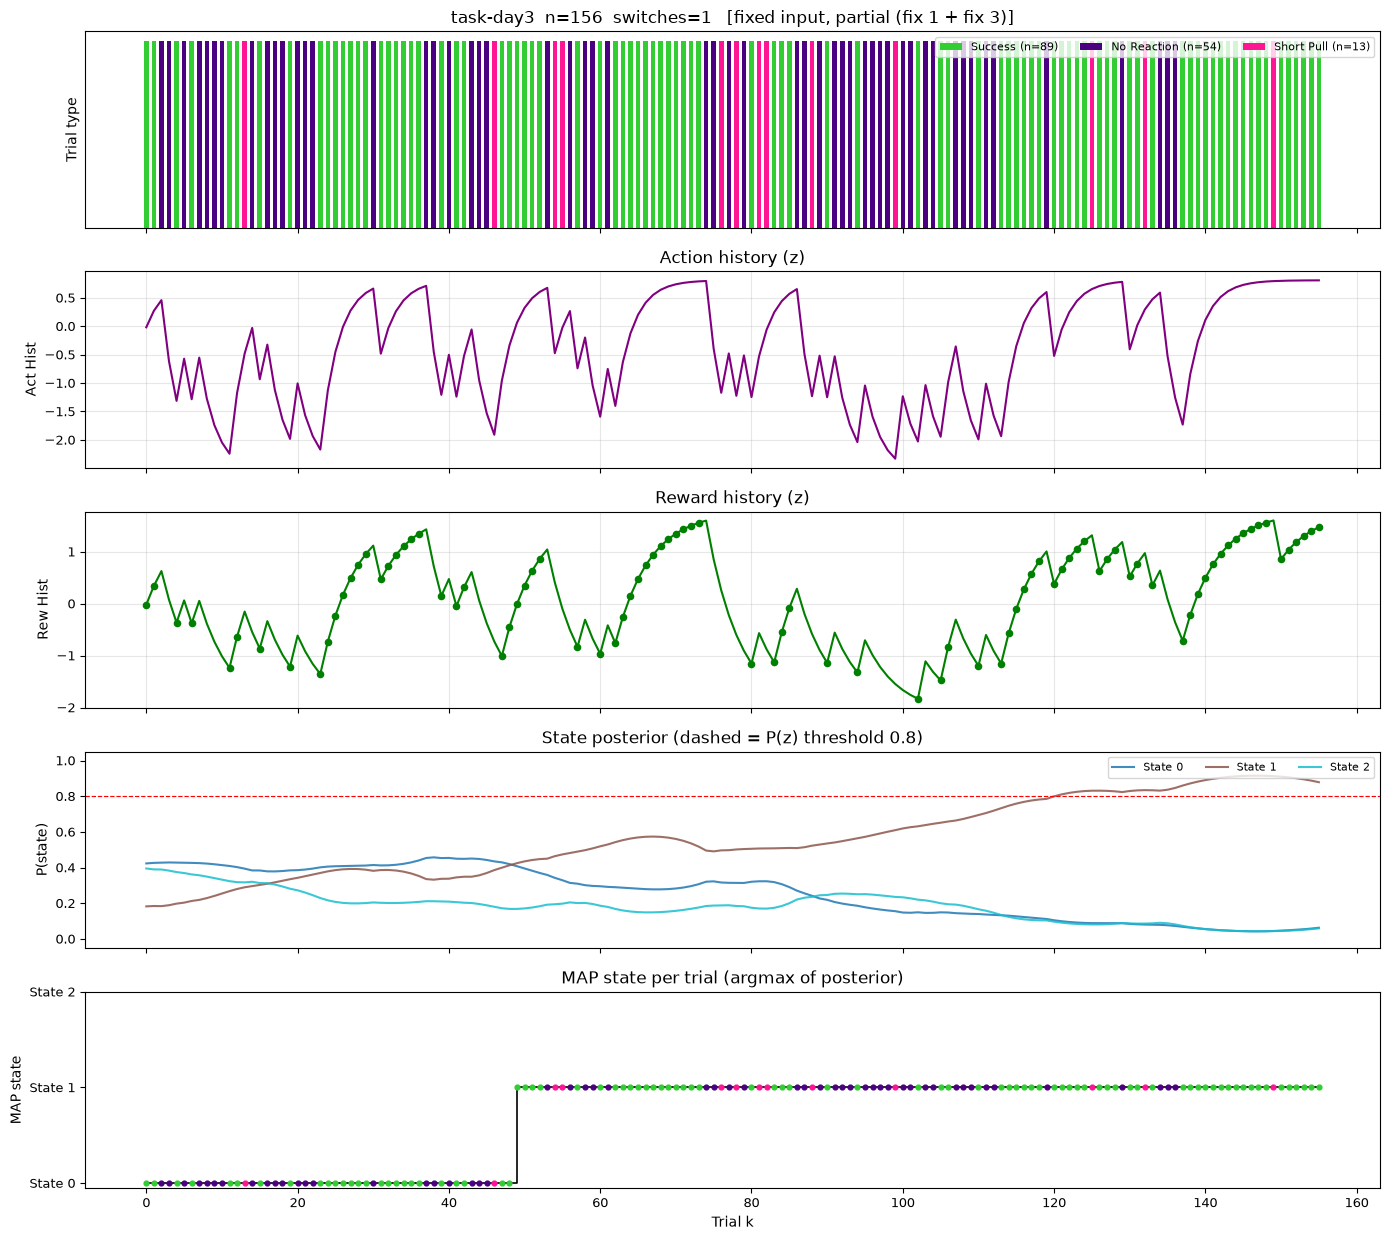

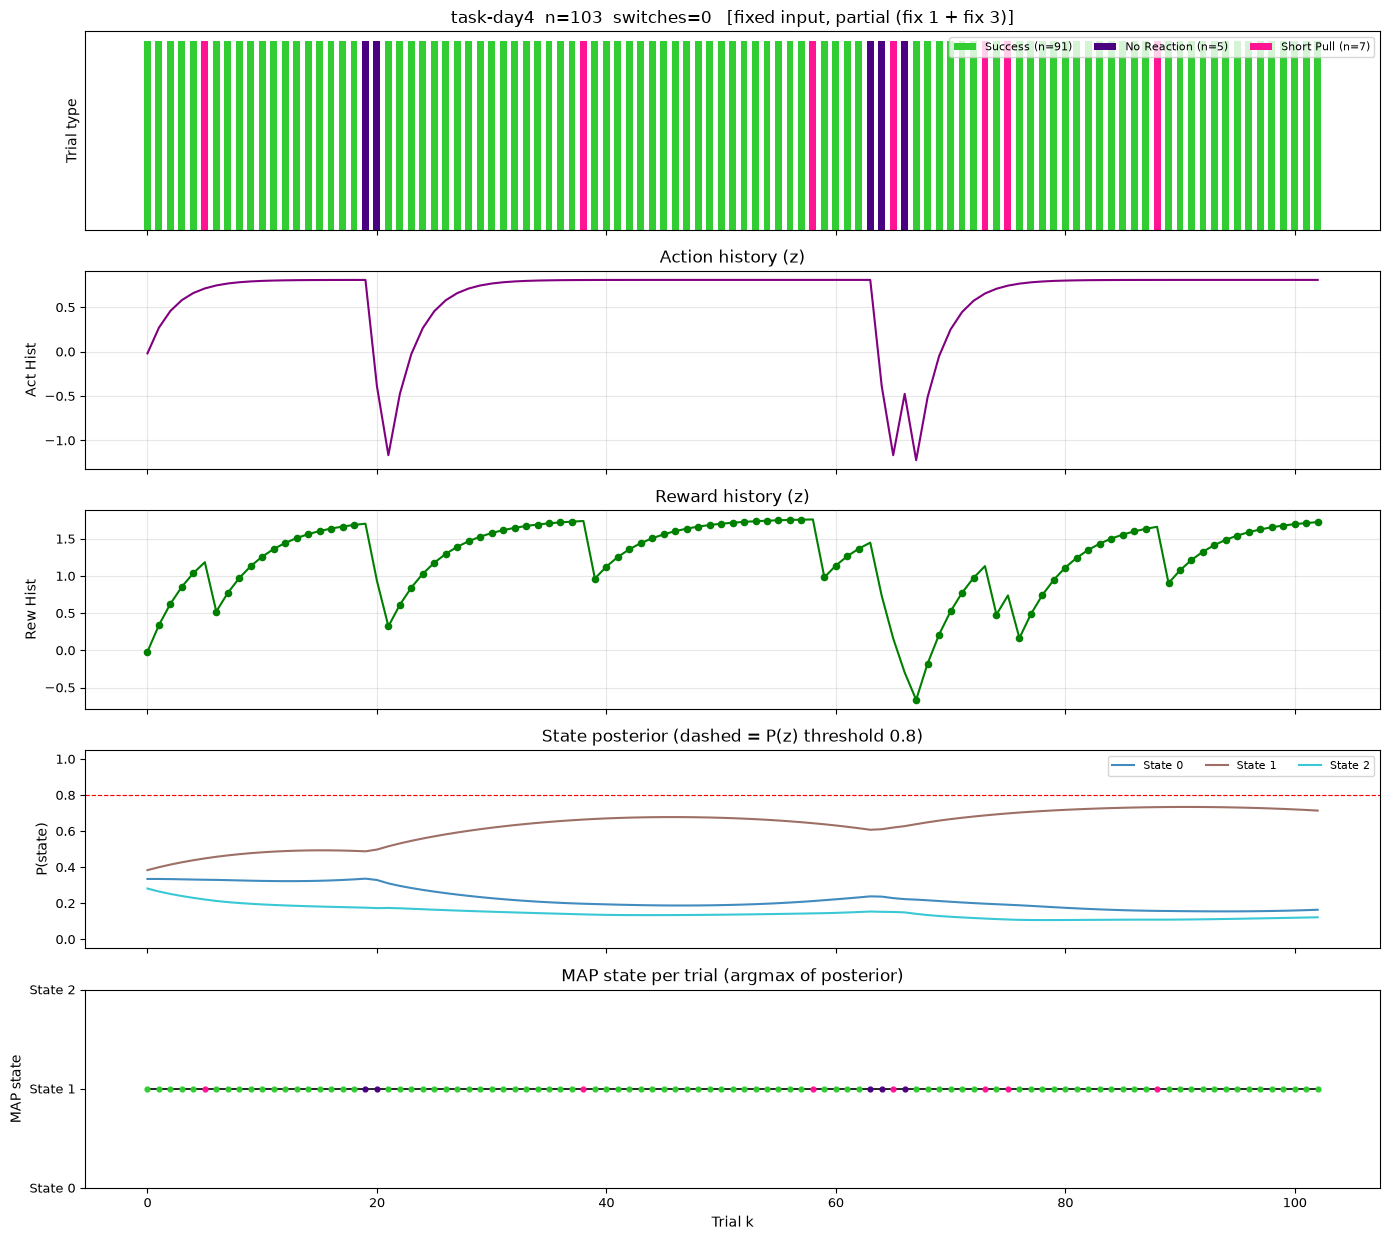

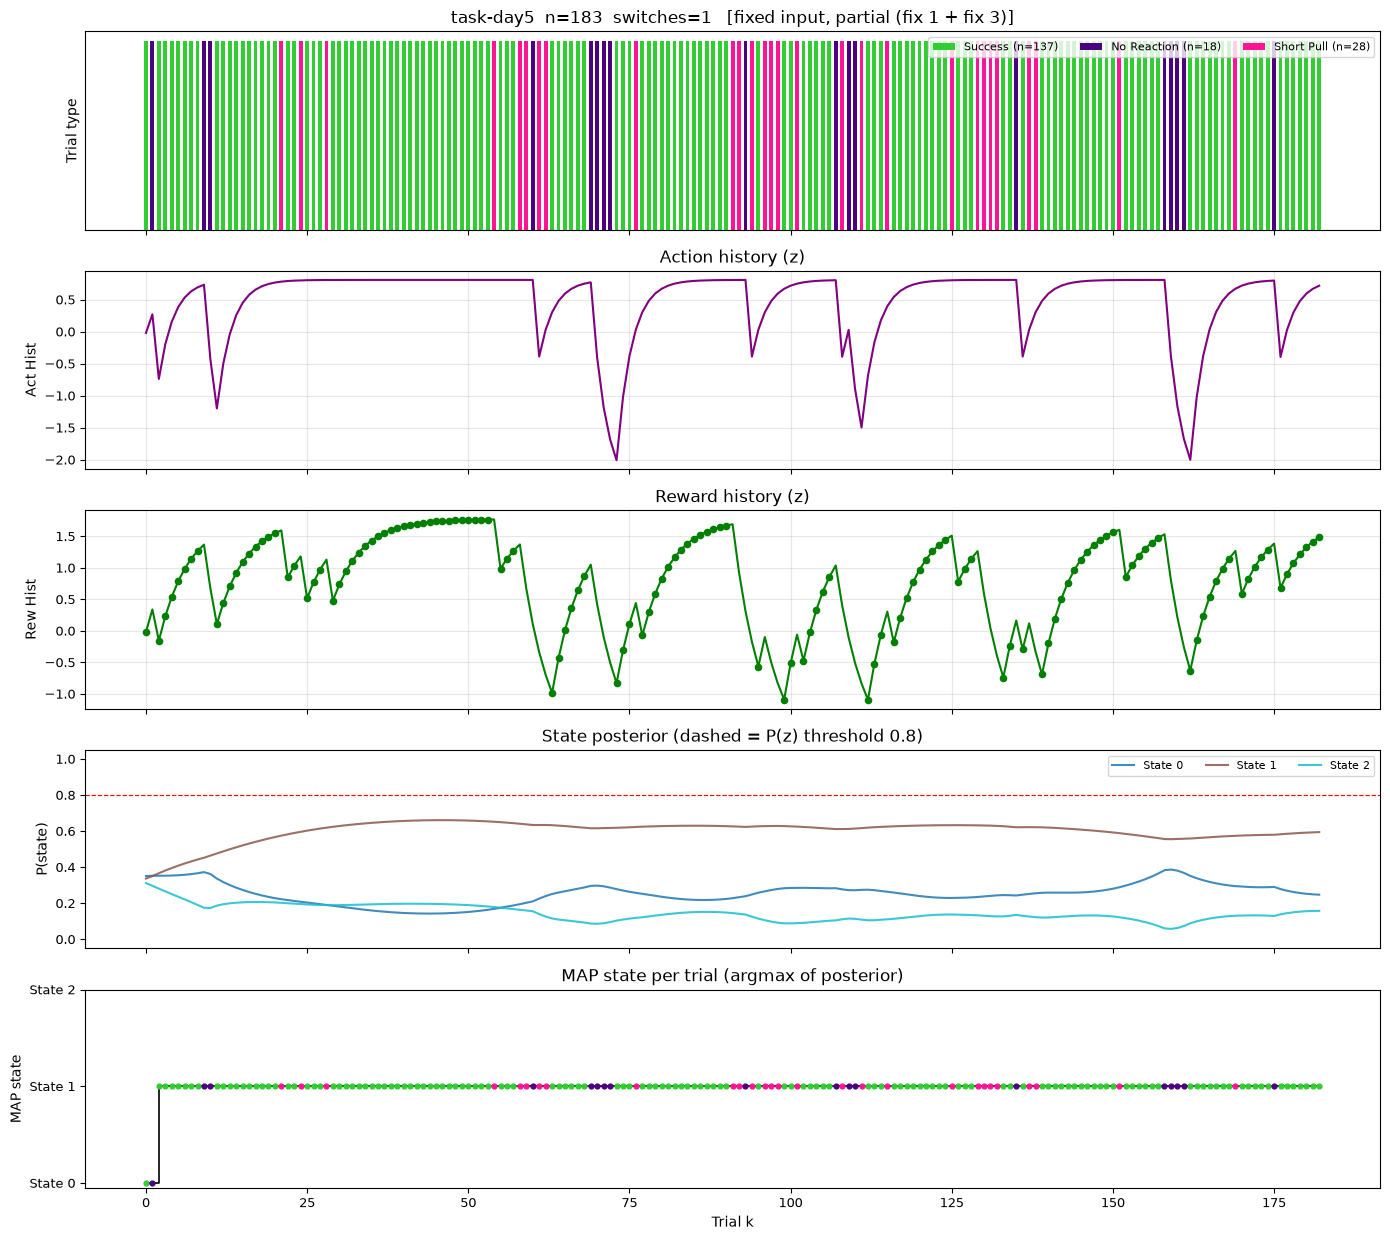

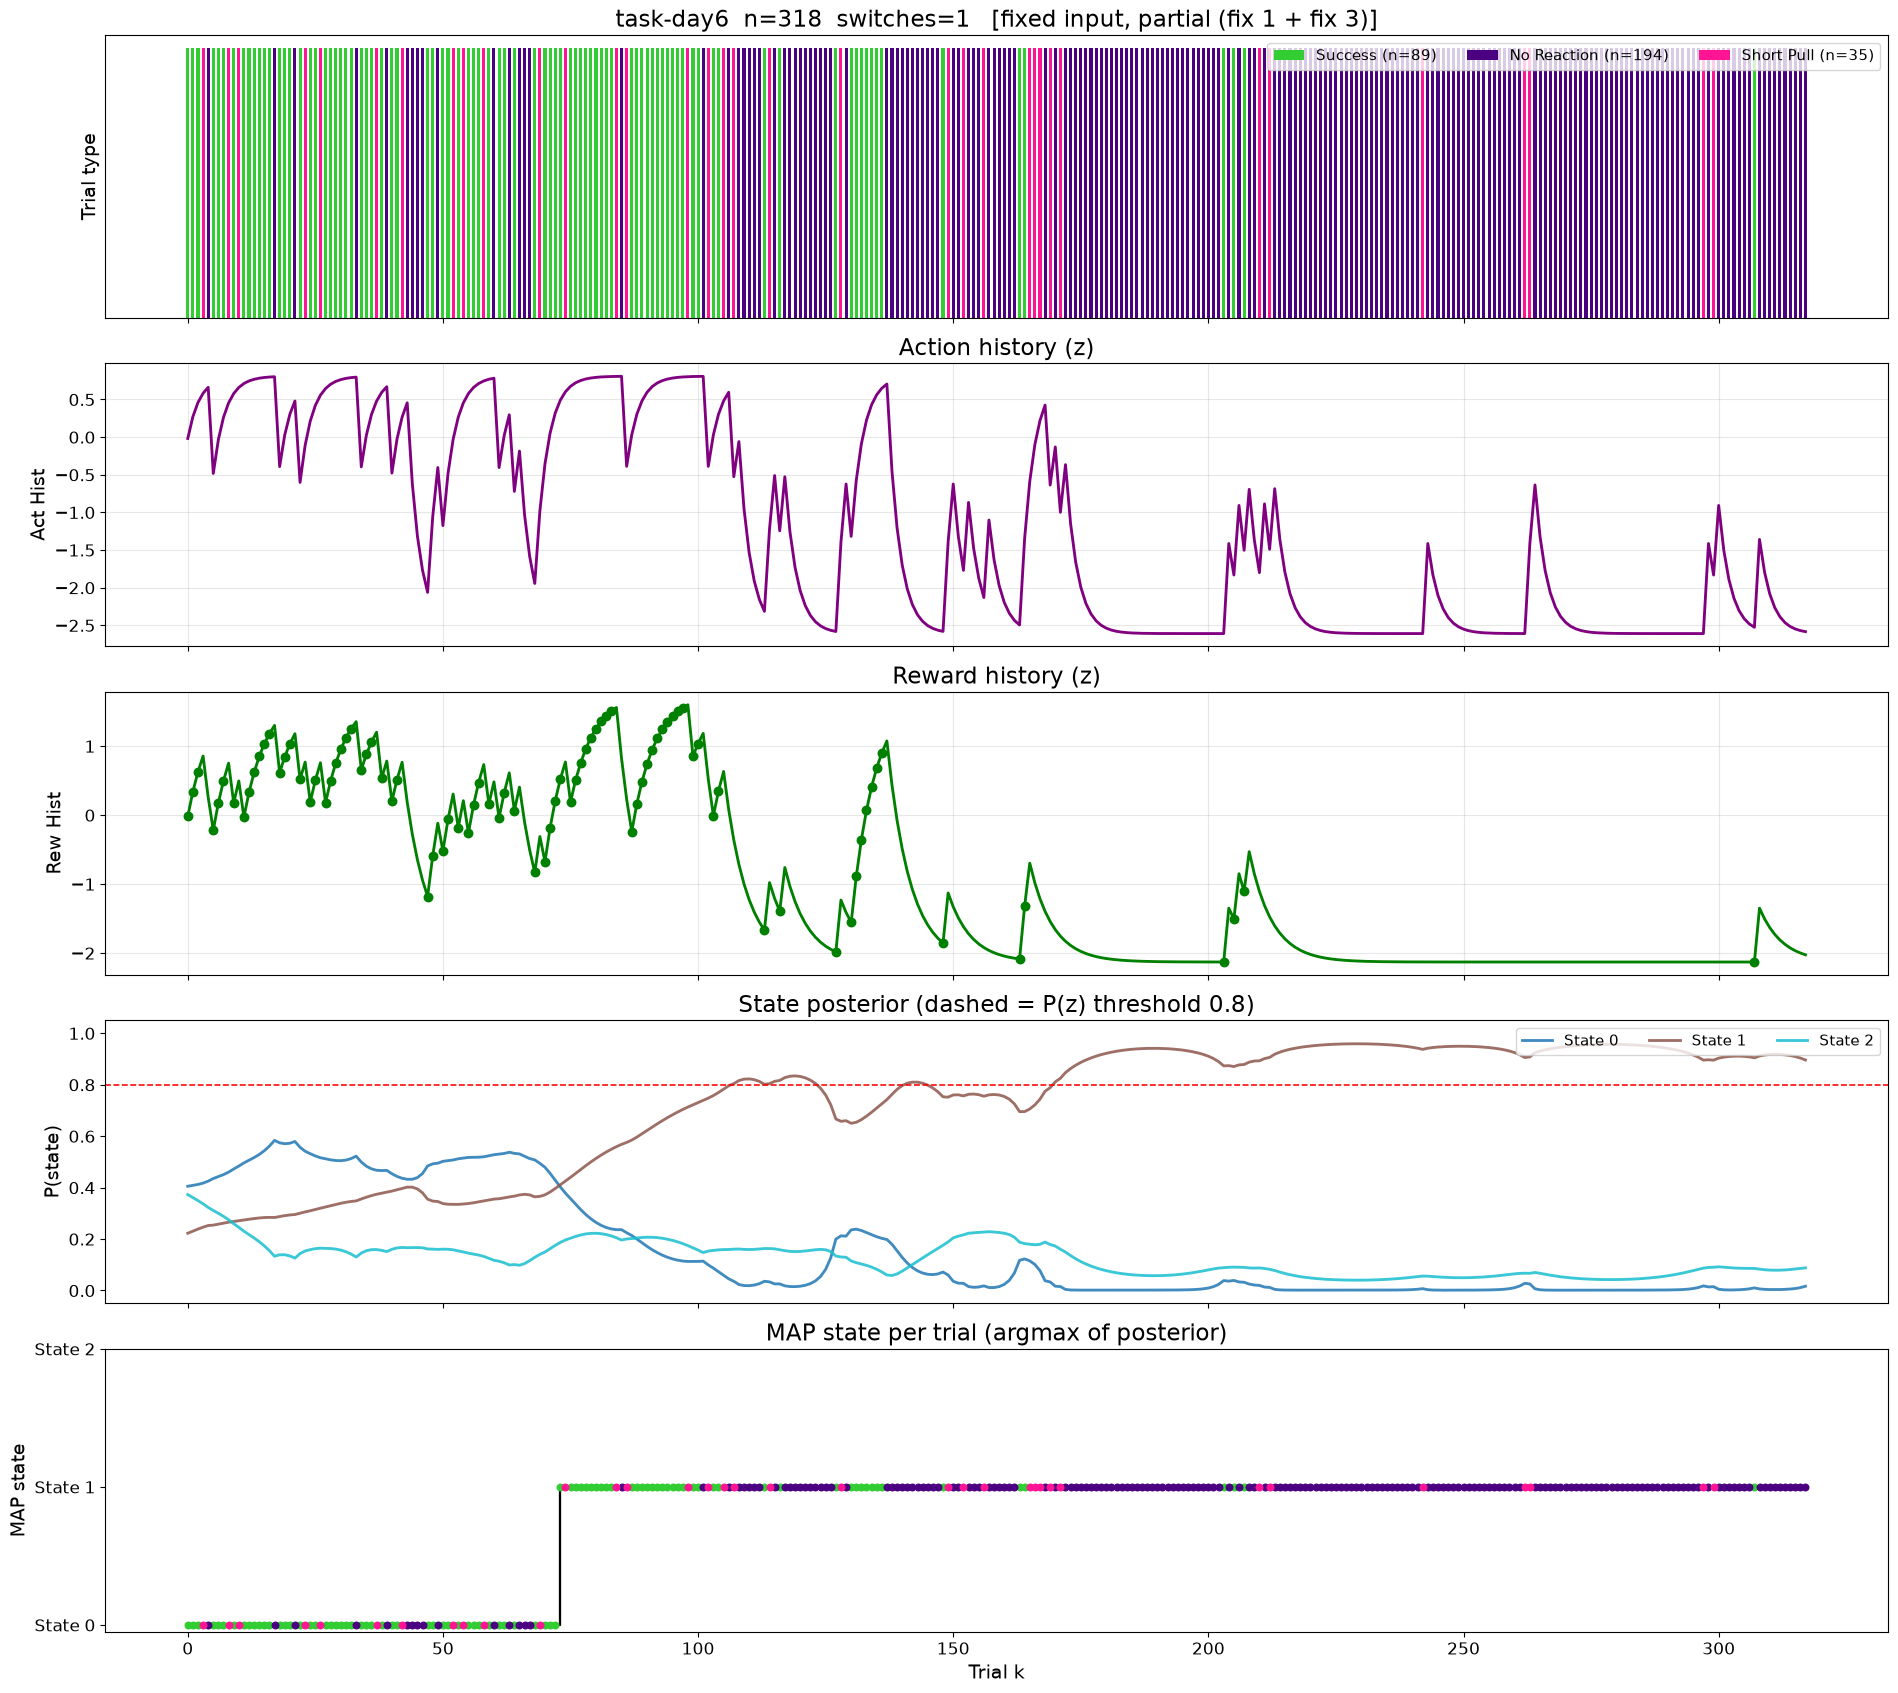

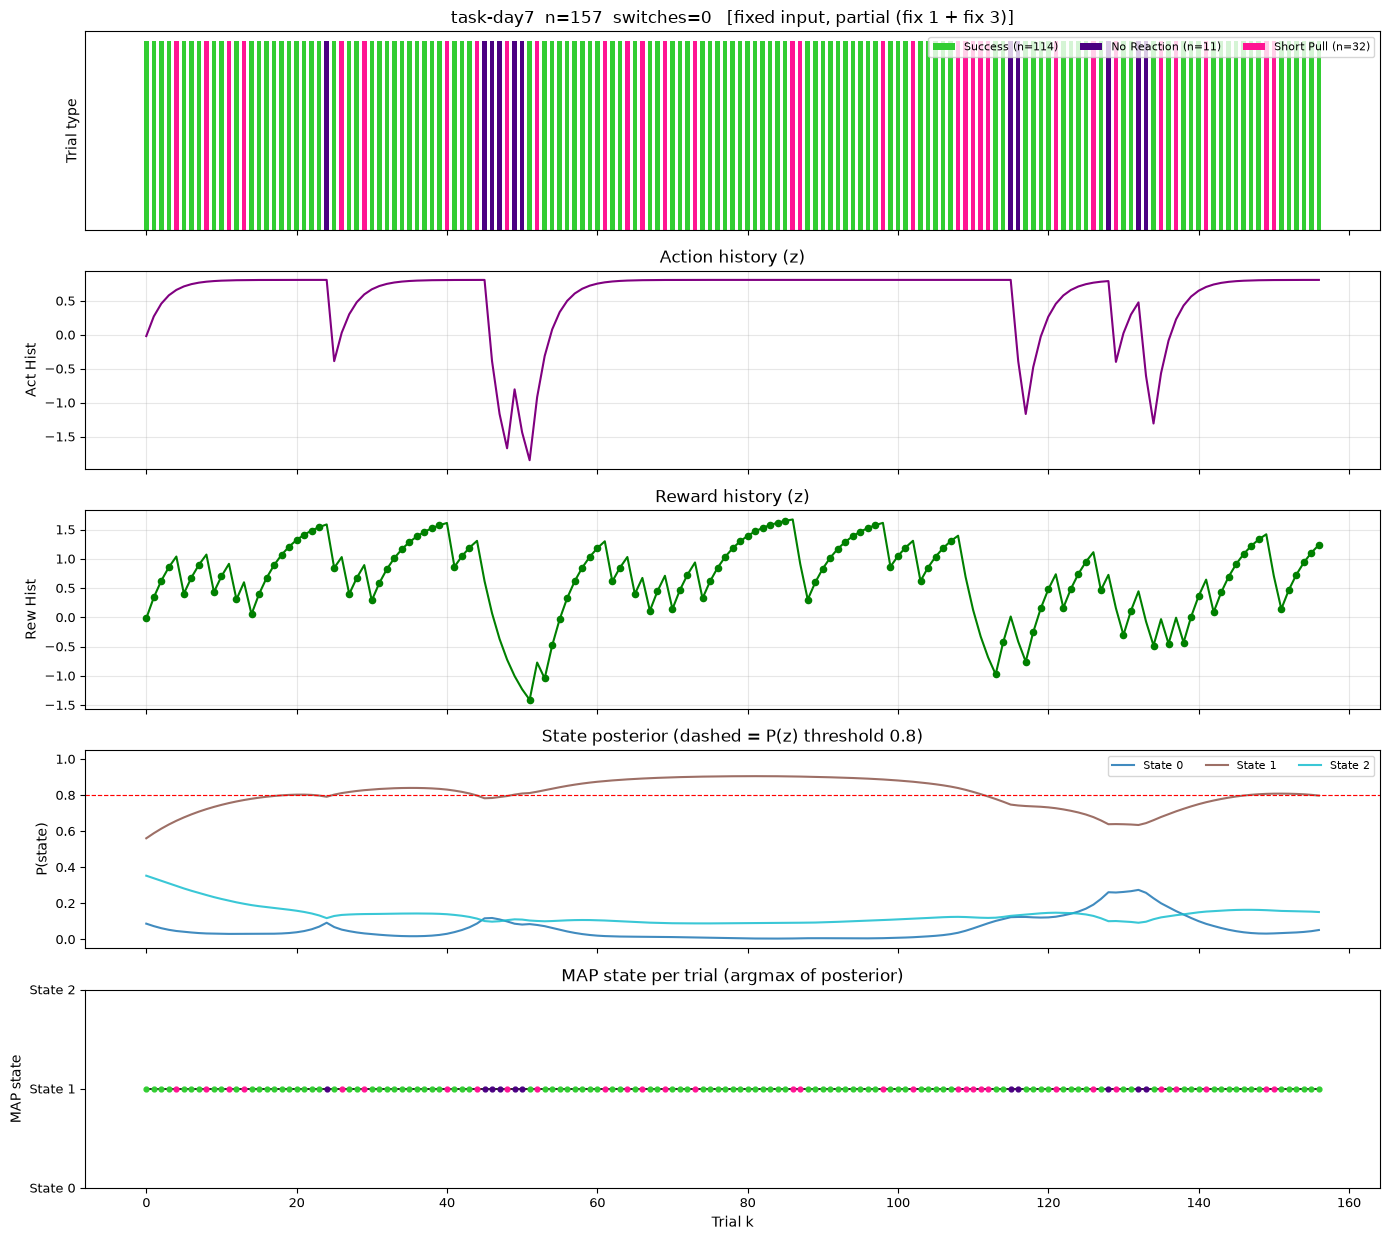

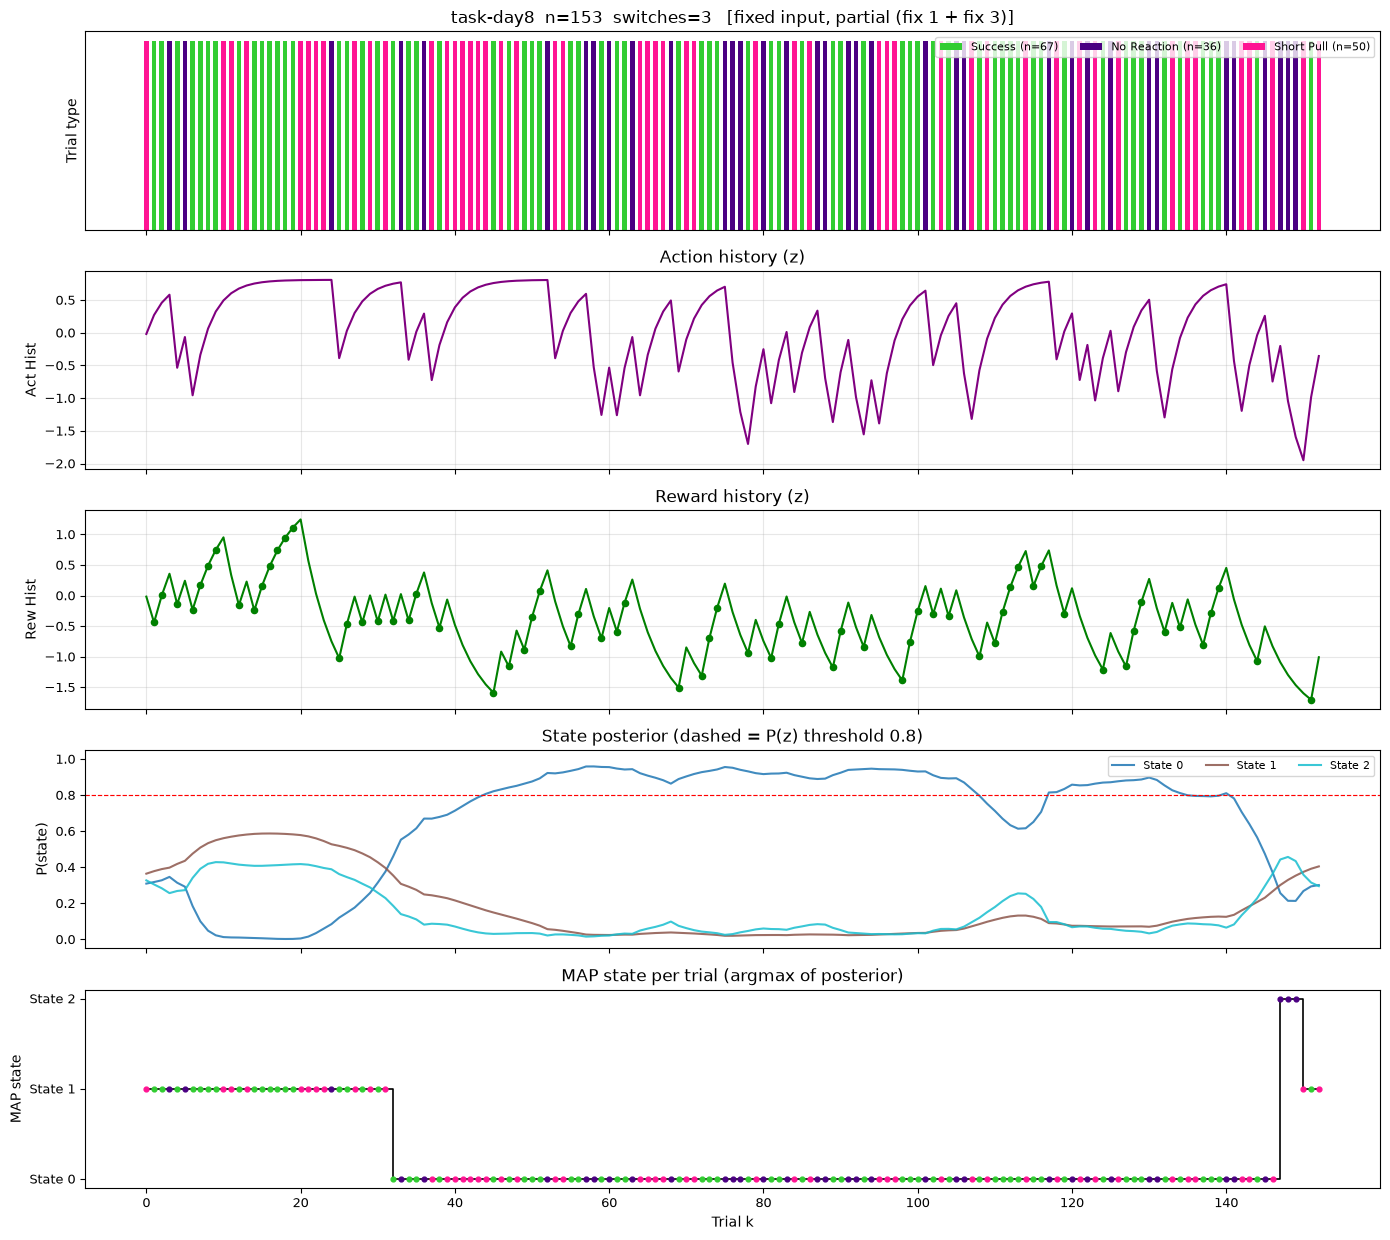

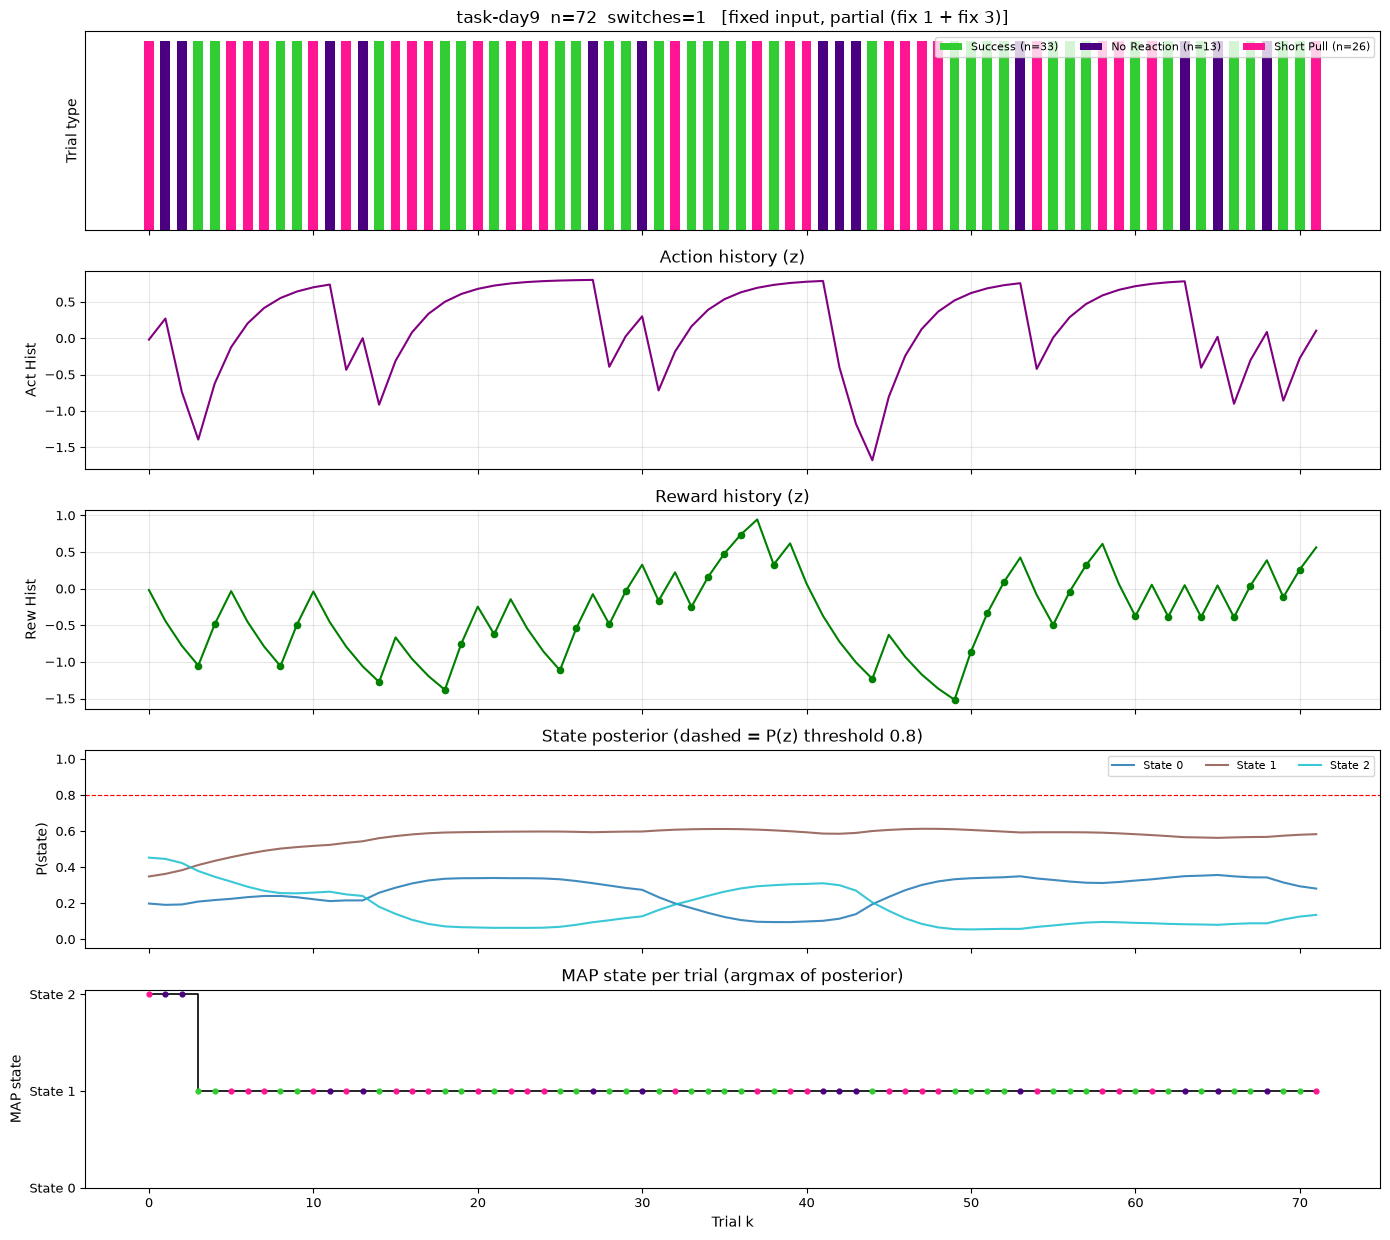

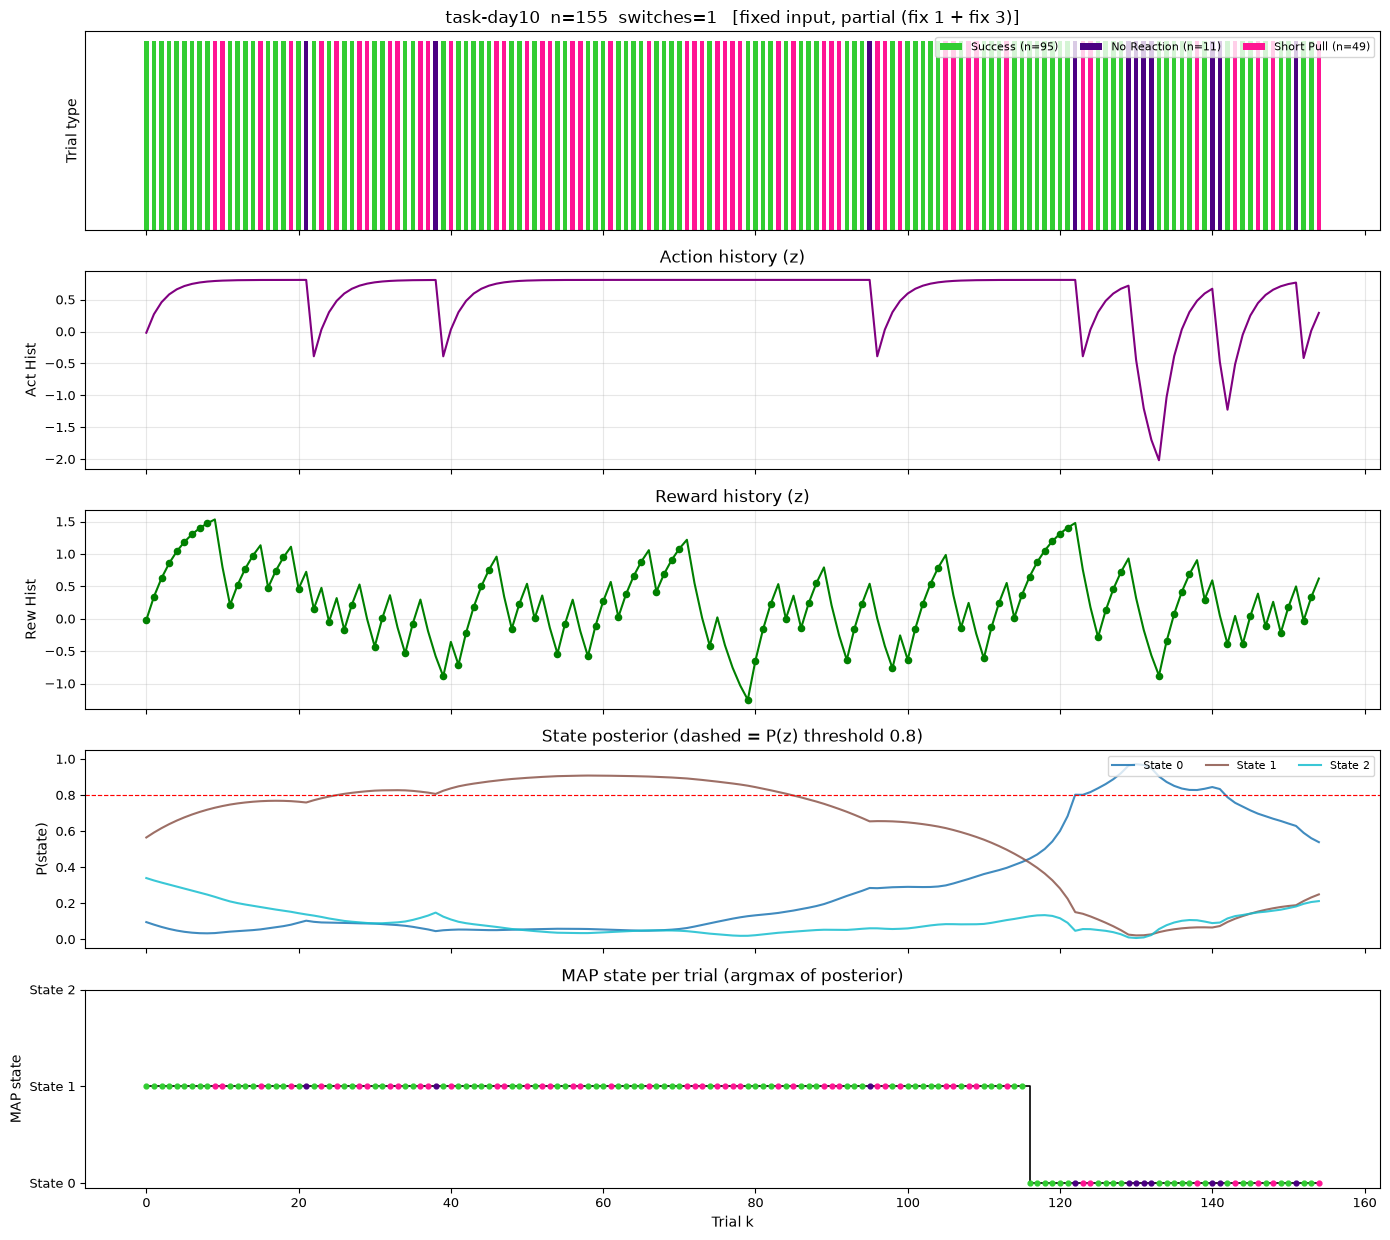

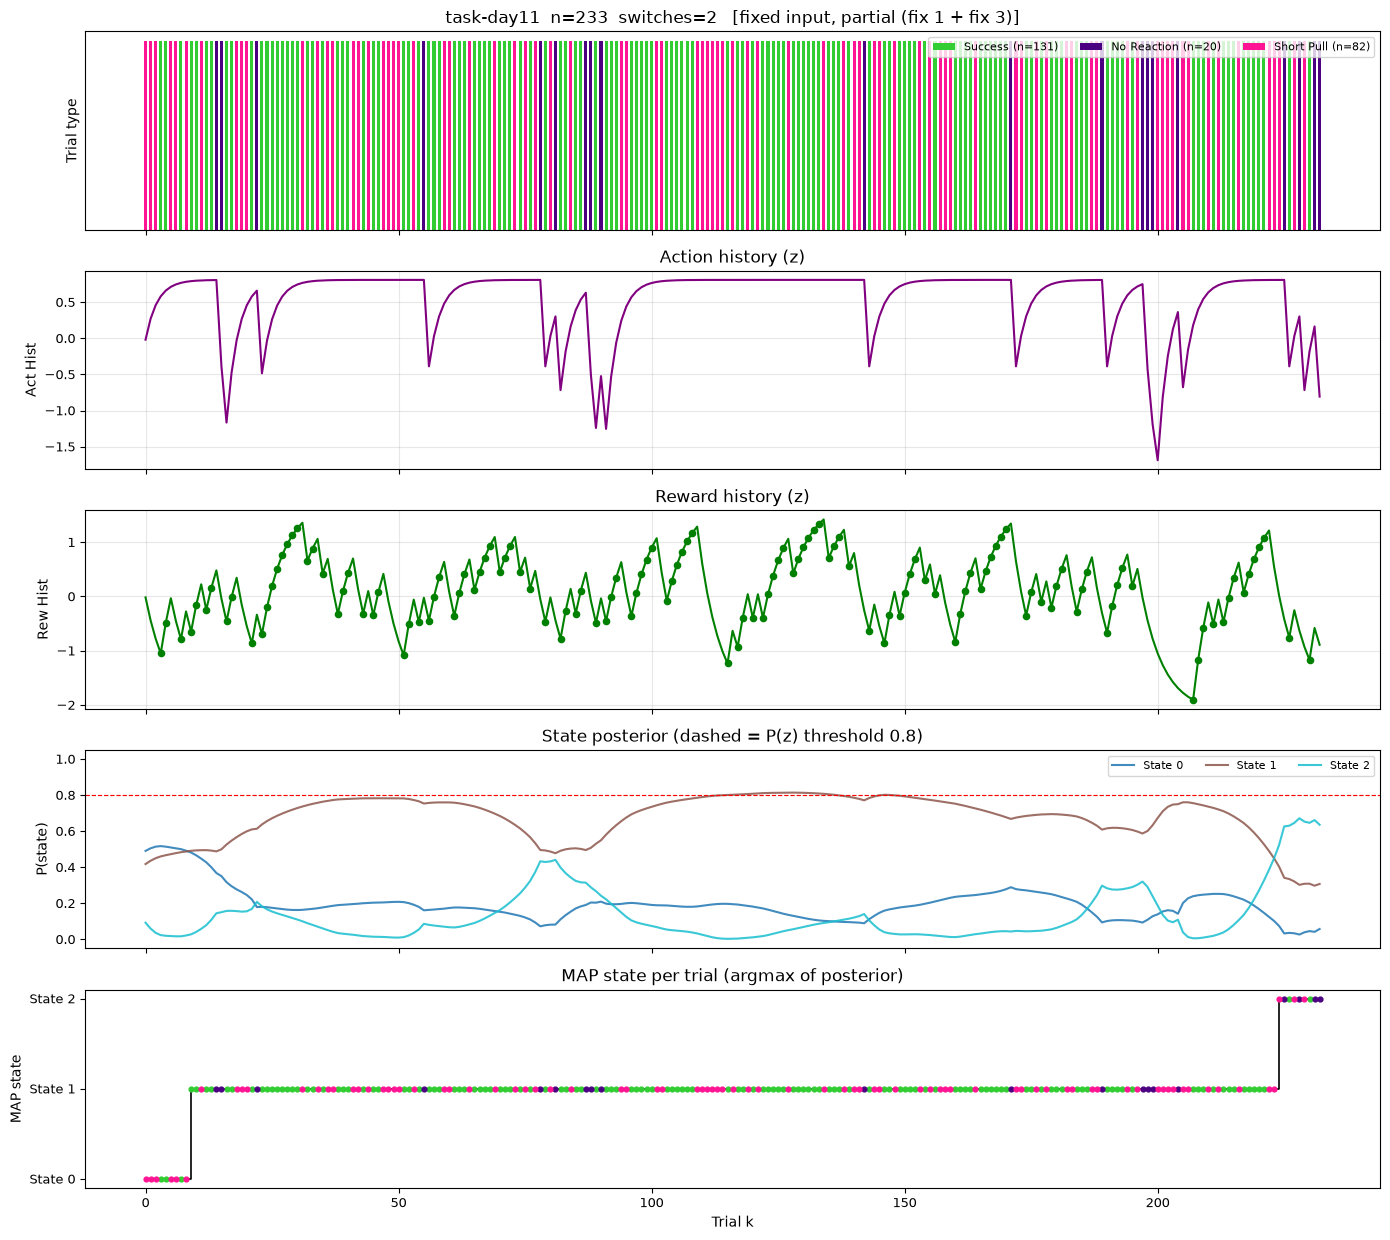

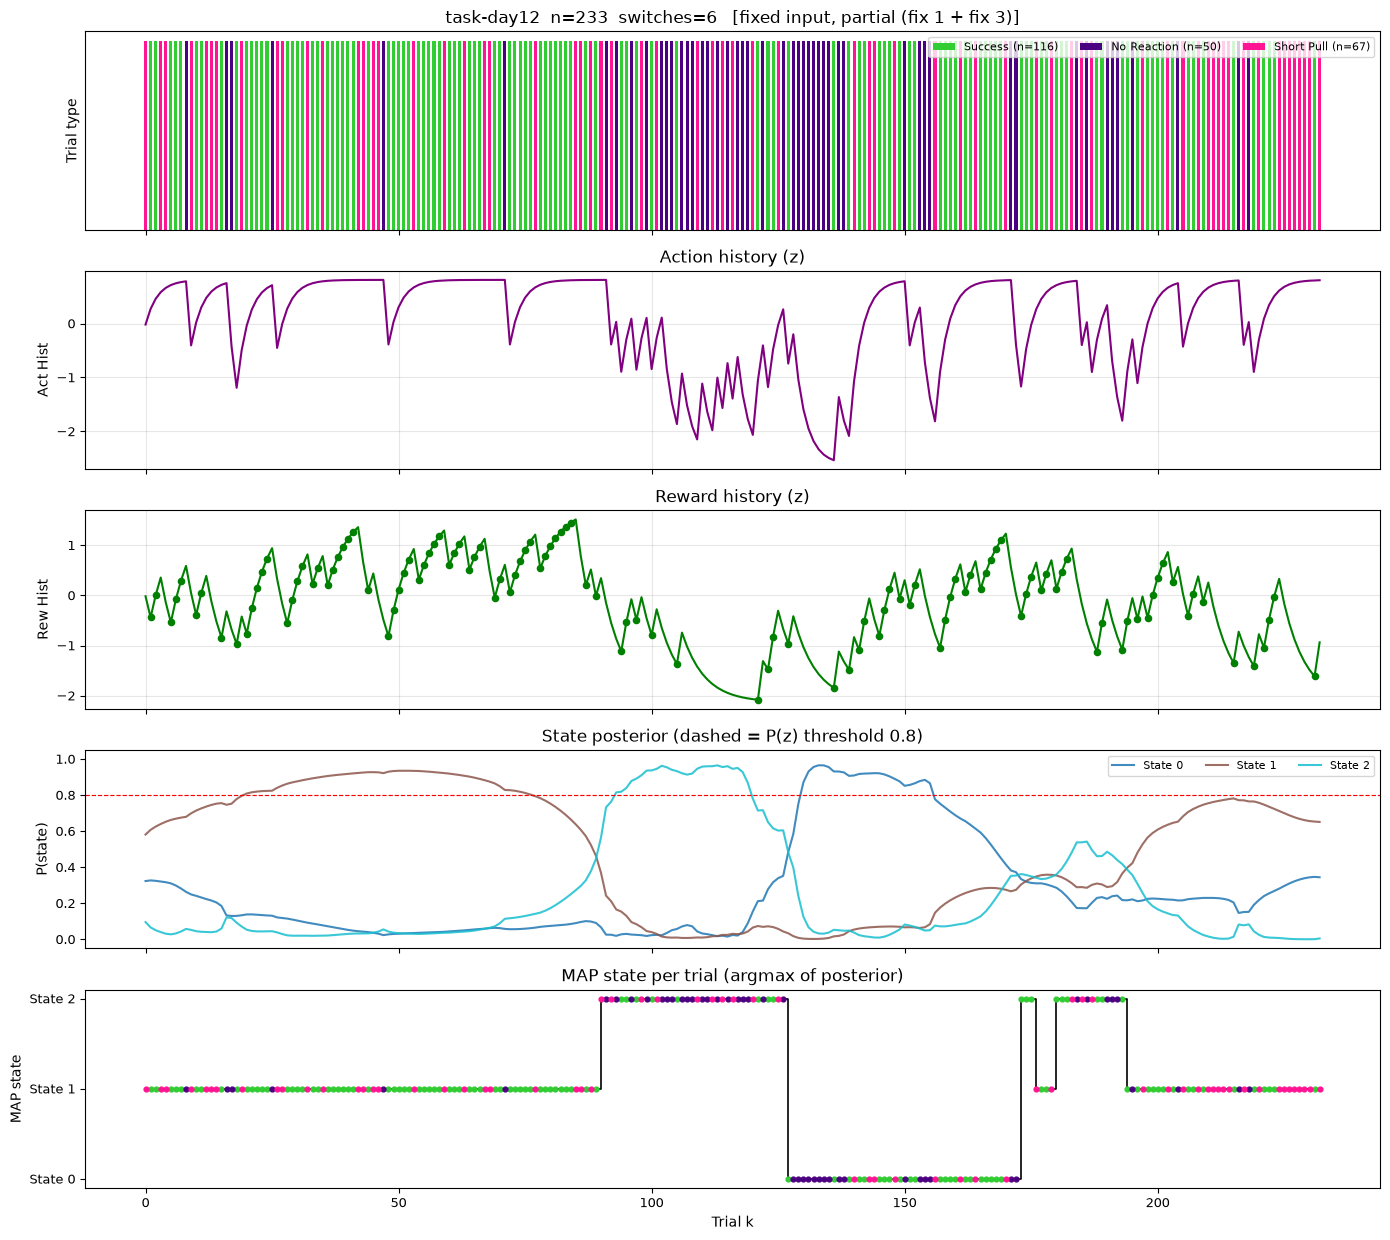

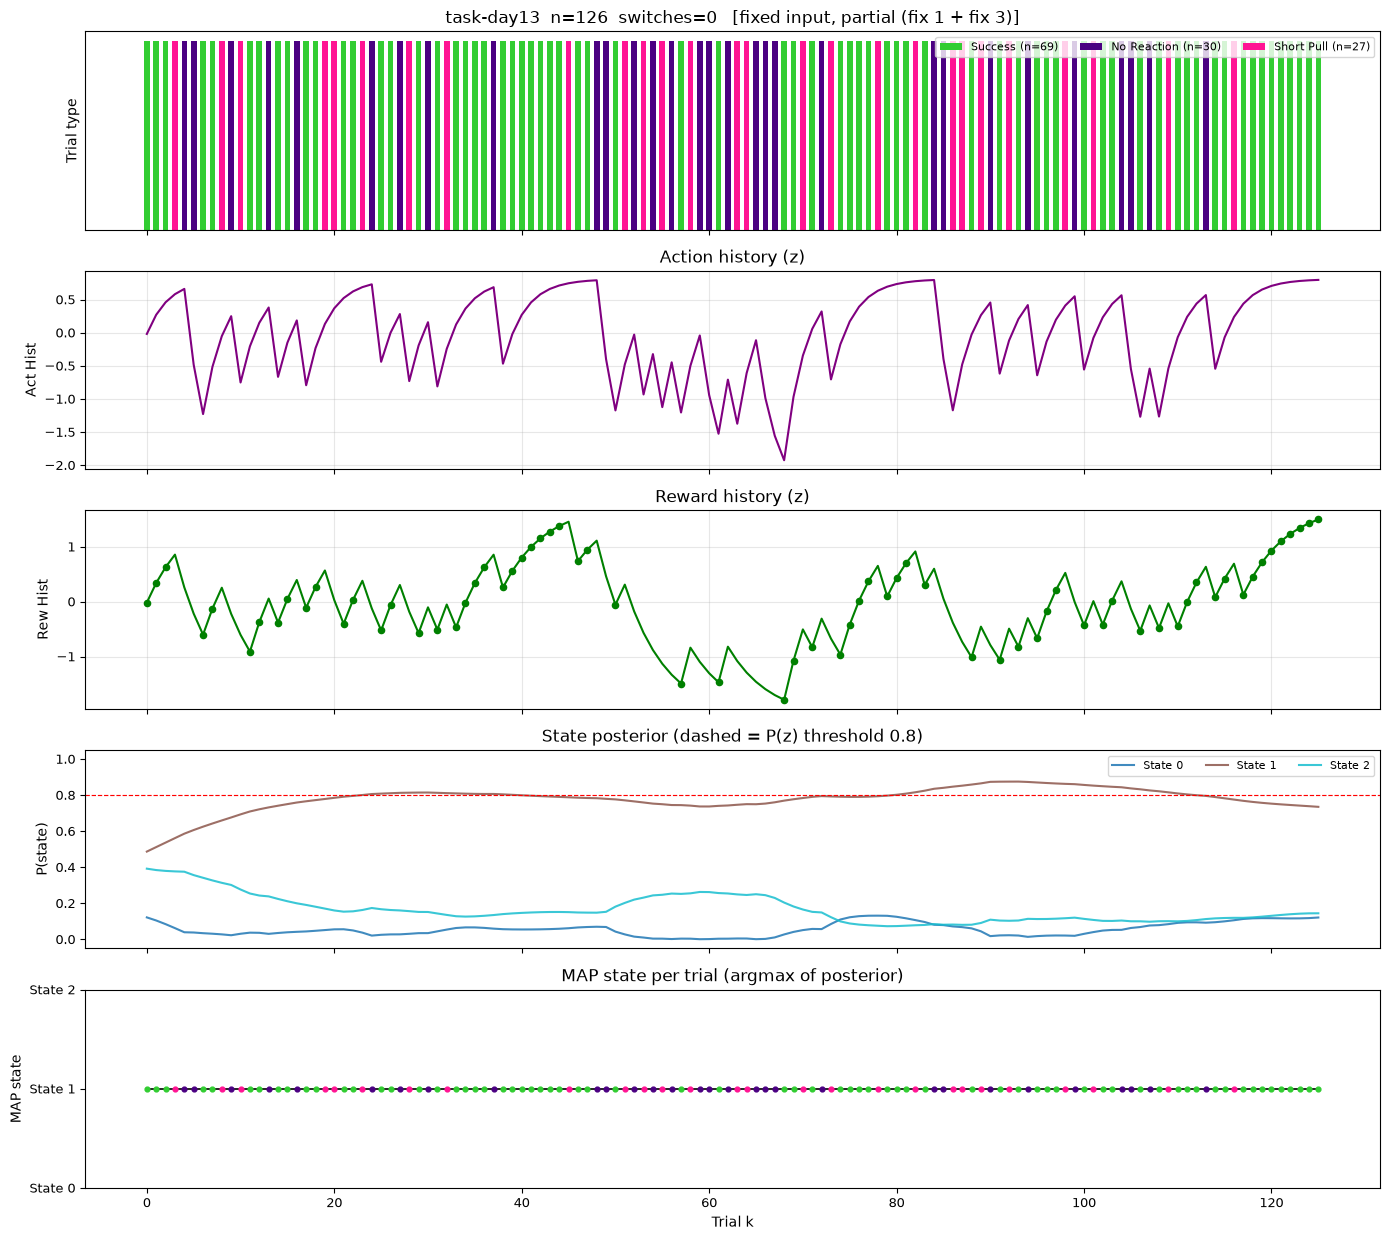

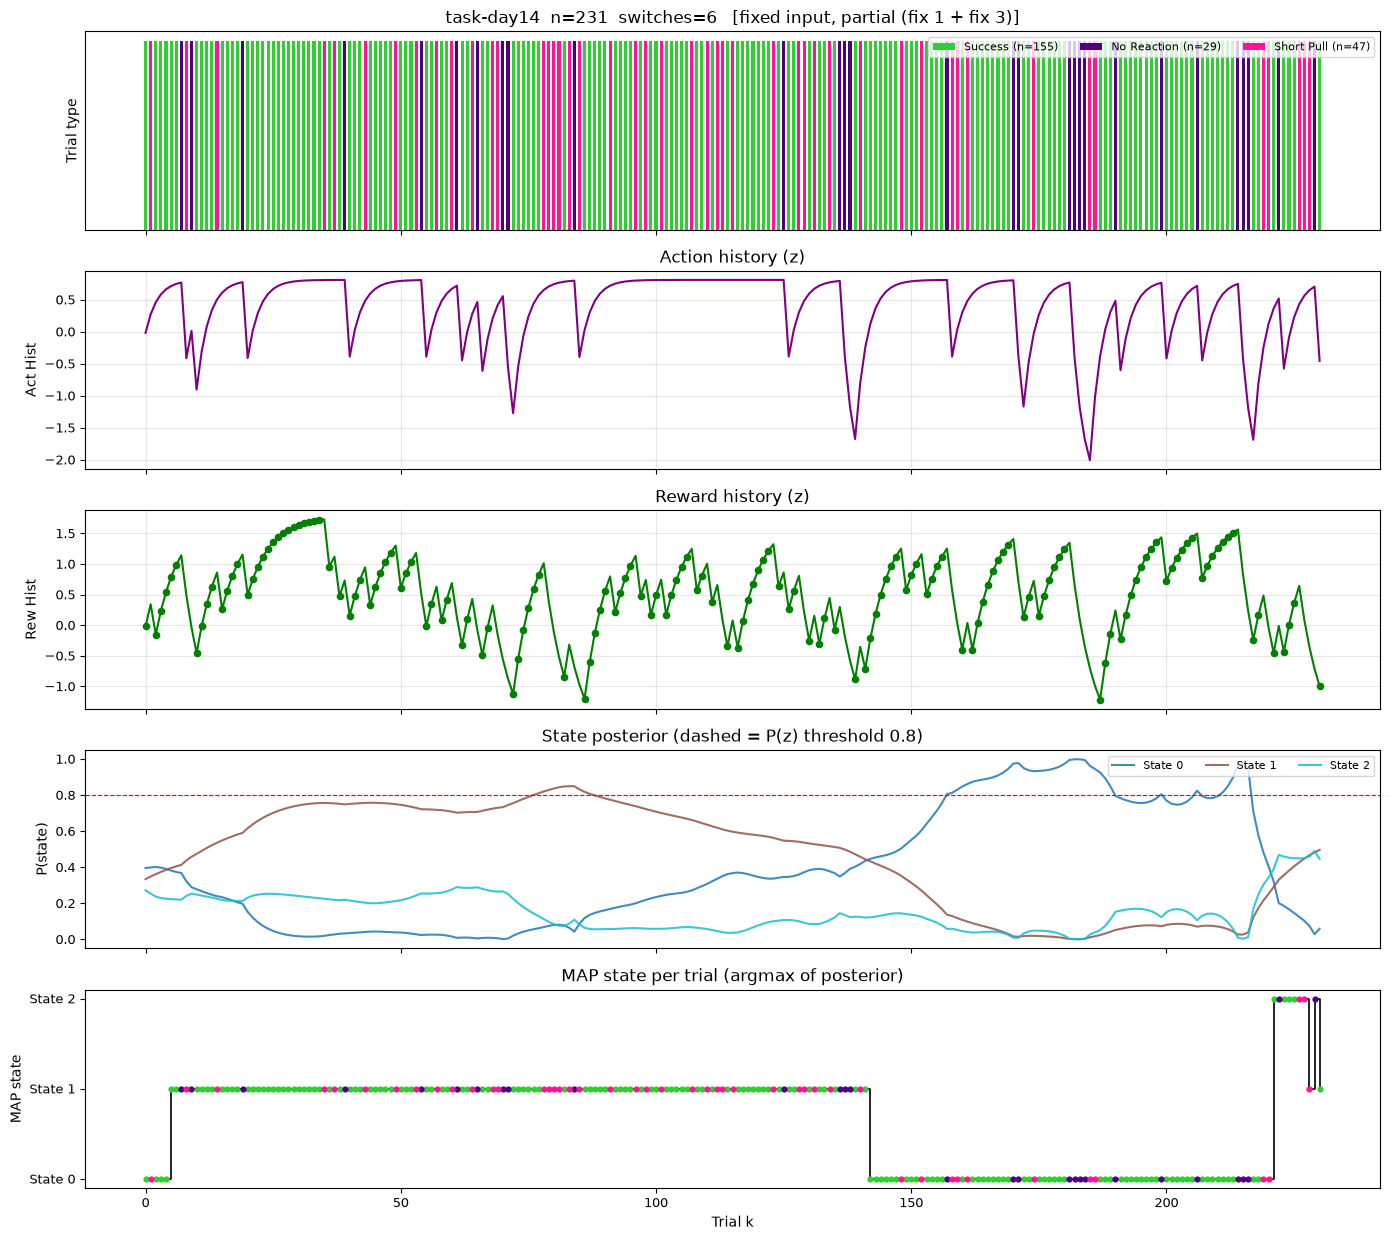

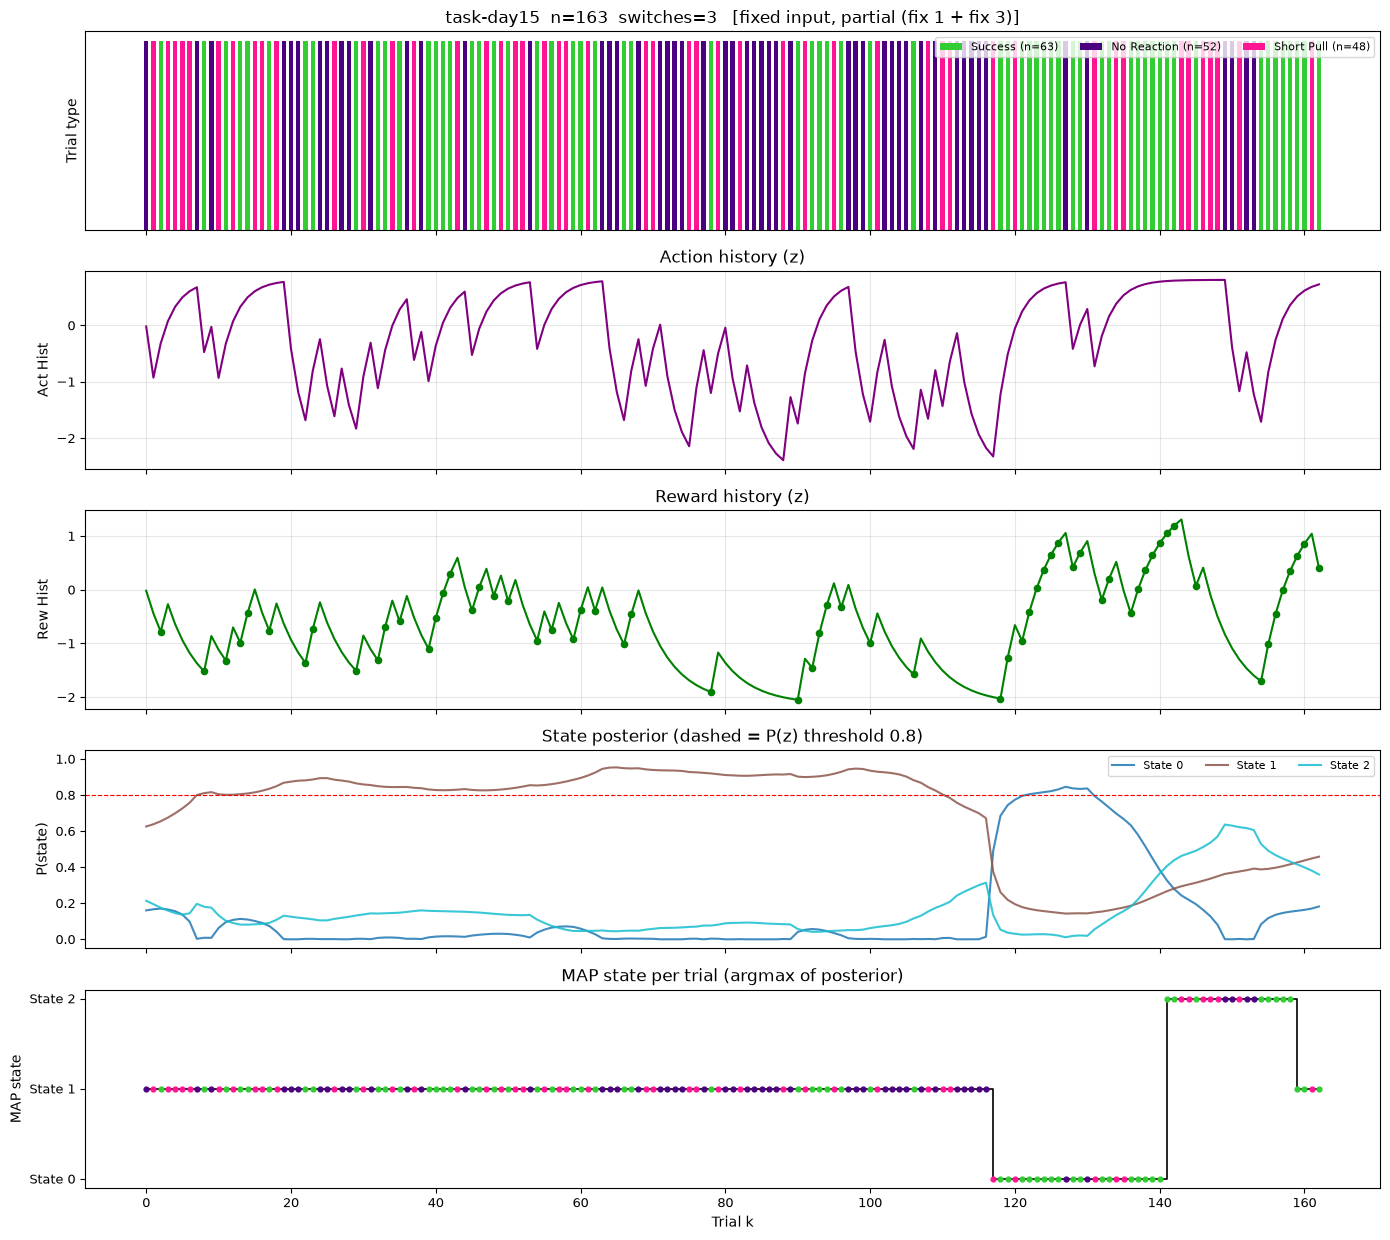

In [16]:
STATE_COLORS = plt.cm.tab10(np.linspace(0, 1, K))


def day_panel_full(tr, sm, i, label=''):
    '''note16 の v4.plot_day_panel と同じ構成（Stimulus 段は Ver.5 に無いので5段）。'''
    d = DAYS[i]
    sl = slice(SESS[i], SESS[i + 1])
    g = tr.iloc[sl]
    prob = sm['gamma'][sl]
    z = sm['z'][sl]
    t = np.arange(len(g))
    ttypes = g['trial_type'].to_numpy()

    fig_width = min(60, max(14, len(t) * 0.06))
    fig_height = fig_width * (12.5 / 14)
    scale = fig_width / 14
    title_fs, label_fs, tick_fs, legend_fs = 12 * scale, 10 * scale, 9 * scale, 8 * scale
    lw_thin, lw_step = 1.5 * scale, 1.2 * scale
    s_reward, s_map = 20 * scale ** 2, 12 * scale ** 2

    fig, axes = plt.subplots(5, 1, figsize=(fig_width, fig_height), sharex=True)

    for ttype, color in v4.TRIAL_TYPE_COLORS.items():
        idx = ttypes == ttype
        if idx.any():
            axes[0].bar(t[idx], 1, width=0.6, color=color, linewidth=0,
                        label=f'{ttype} (n={int(idx.sum())})')
    axes[0].set_yticks([])
    axes[0].set_ylabel('Trial type', fontsize=label_fs)
    axes[0].set_title(f'{d}  n={len(t)}  switches={sm["switches"][i]}'
                      + (f'   [{label}]' if label else ''), fontsize=title_fs)
    axes[0].legend(loc='upper right', ncol=3, fontsize=legend_fs)

    axes[1].plot(t, g['x_hist_z'].to_numpy(), color='purple', linewidth=lw_thin)
    axes[1].set_ylabel('Act Hist', fontsize=label_fs)
    axes[1].set_title('Action history (z)', fontsize=title_fs)
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(t, g['x_rew_z'].to_numpy(), color='green', linewidth=lw_thin)
    rew = ttypes == 'Success'
    if rew.any():
        axes[2].scatter(t[rew], g['x_rew_z'].to_numpy()[rew], color='green',
                        s=s_reward, zorder=5)
    axes[2].set_ylabel('Rew Hist', fontsize=label_fs)
    axes[2].set_title('Reward history (z)', fontsize=title_fs)
    axes[2].grid(True, alpha=0.3)

    for k in range(K):
        axes[3].plot(t, prob[:, k], label=f'State {k}', color=STATE_COLORS[k],
                     alpha=0.85, linewidth=lw_thin)
    axes[3].axhline(P_THRESHOLD, color='r', ls='--', lw=lw_step * 0.7)
    axes[3].set_ylabel('P(state)', fontsize=label_fs)
    axes[3].set_title(f'State posterior (dashed = P(z) threshold {P_THRESHOLD})',
                      fontsize=title_fs)
    axes[3].set_ylim(-0.05, 1.05)
    axes[3].legend(loc='upper right', ncol=K, fontsize=legend_fs)

    axes[4].step(t, z, where='post', color='black', linewidth=lw_step)
    for ttype, color in v4.TRIAL_TYPE_COLORS.items():
        idx = ttypes == ttype
        if idx.any():
            axes[4].scatter(t[idx], z[idx], s=s_map, color=color, zorder=3)
    axes[4].set_yticks(range(K))
    axes[4].set_yticklabels([f'State {k}' for k in range(K)], fontsize=tick_fs)
    axes[4].set_ylabel('MAP state', fontsize=label_fs)
    axes[4].set_title('MAP state per trial (argmax of posterior)', fontsize=title_fs)
    axes[4].set_xlabel('Trial k', fontsize=label_fs)

    for ax in axes:
        ax.tick_params(axis='both', labelsize=tick_fs)
    plt.tight_layout(); plt.show()


for i in range(len(DAYS)):
    day_panel_full(tr_fixed, sm_par_fix, i, 'fixed input, partial (fix 1 + fix 3)')


### 5.2 比較（reset 入力・`'standard'`）

全 day を1枚にまとめた積み上げ図。上端の黒い目盛りが No Reaction 試行。

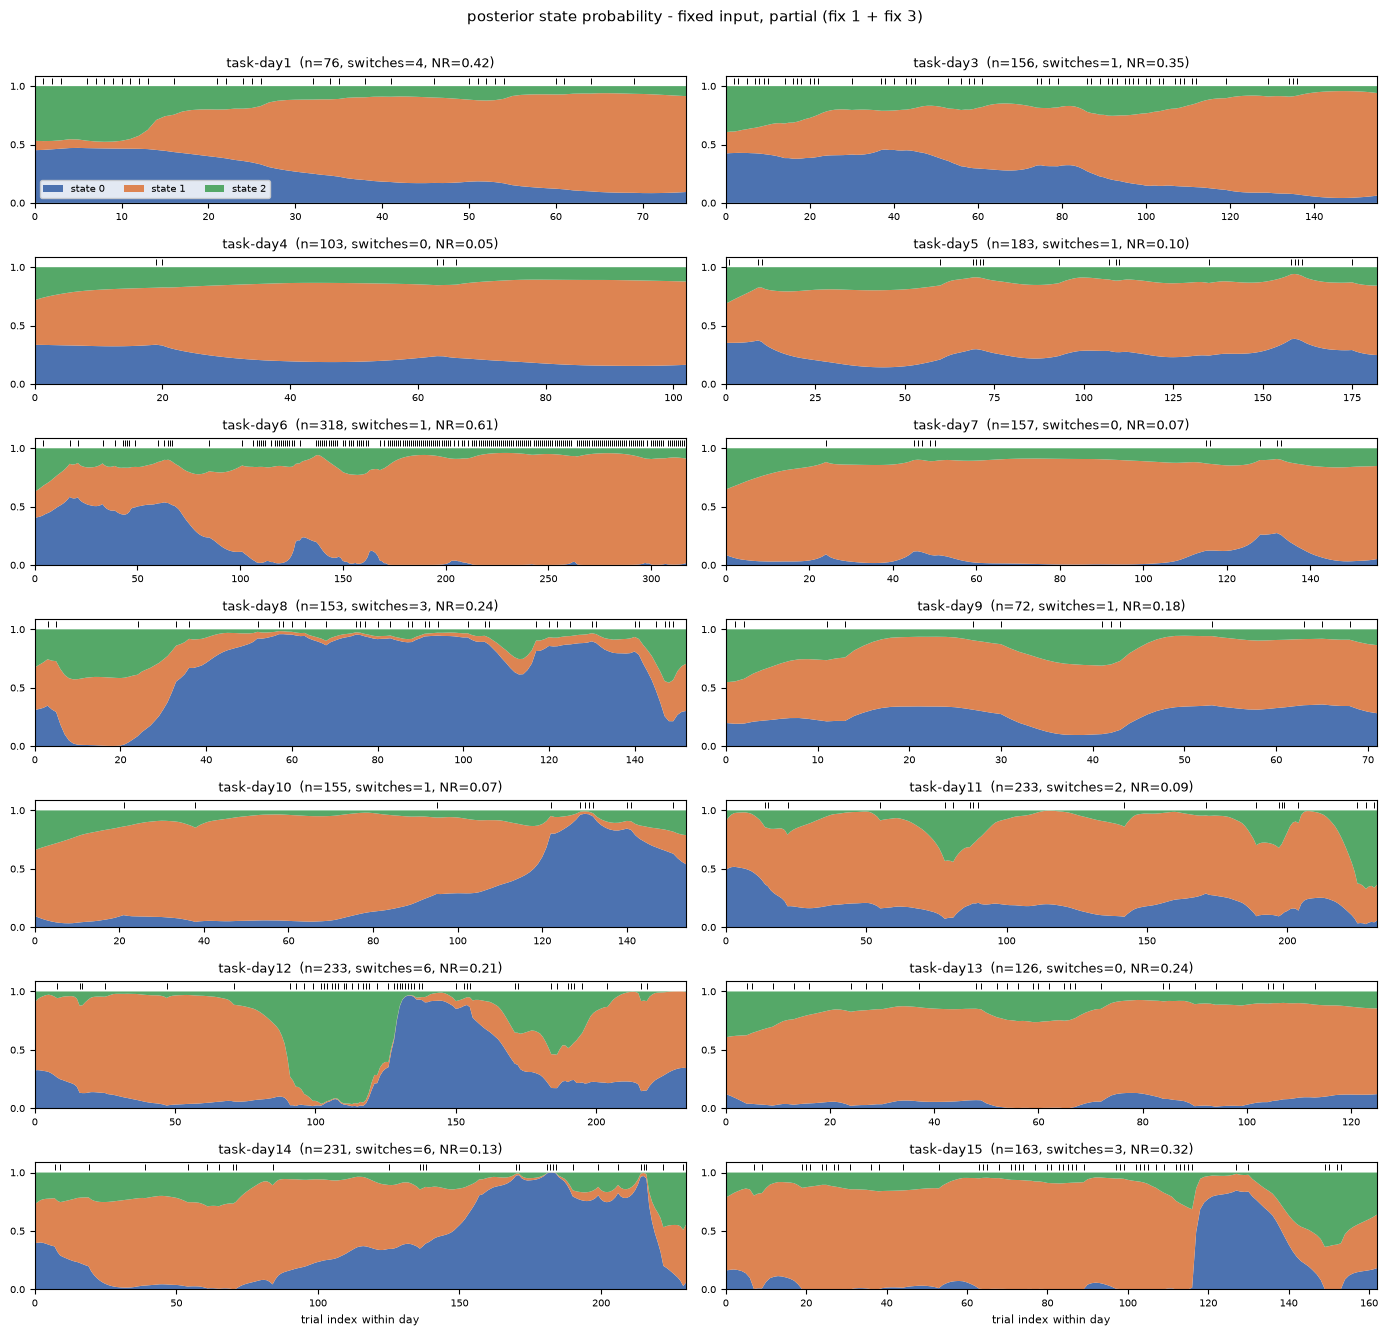

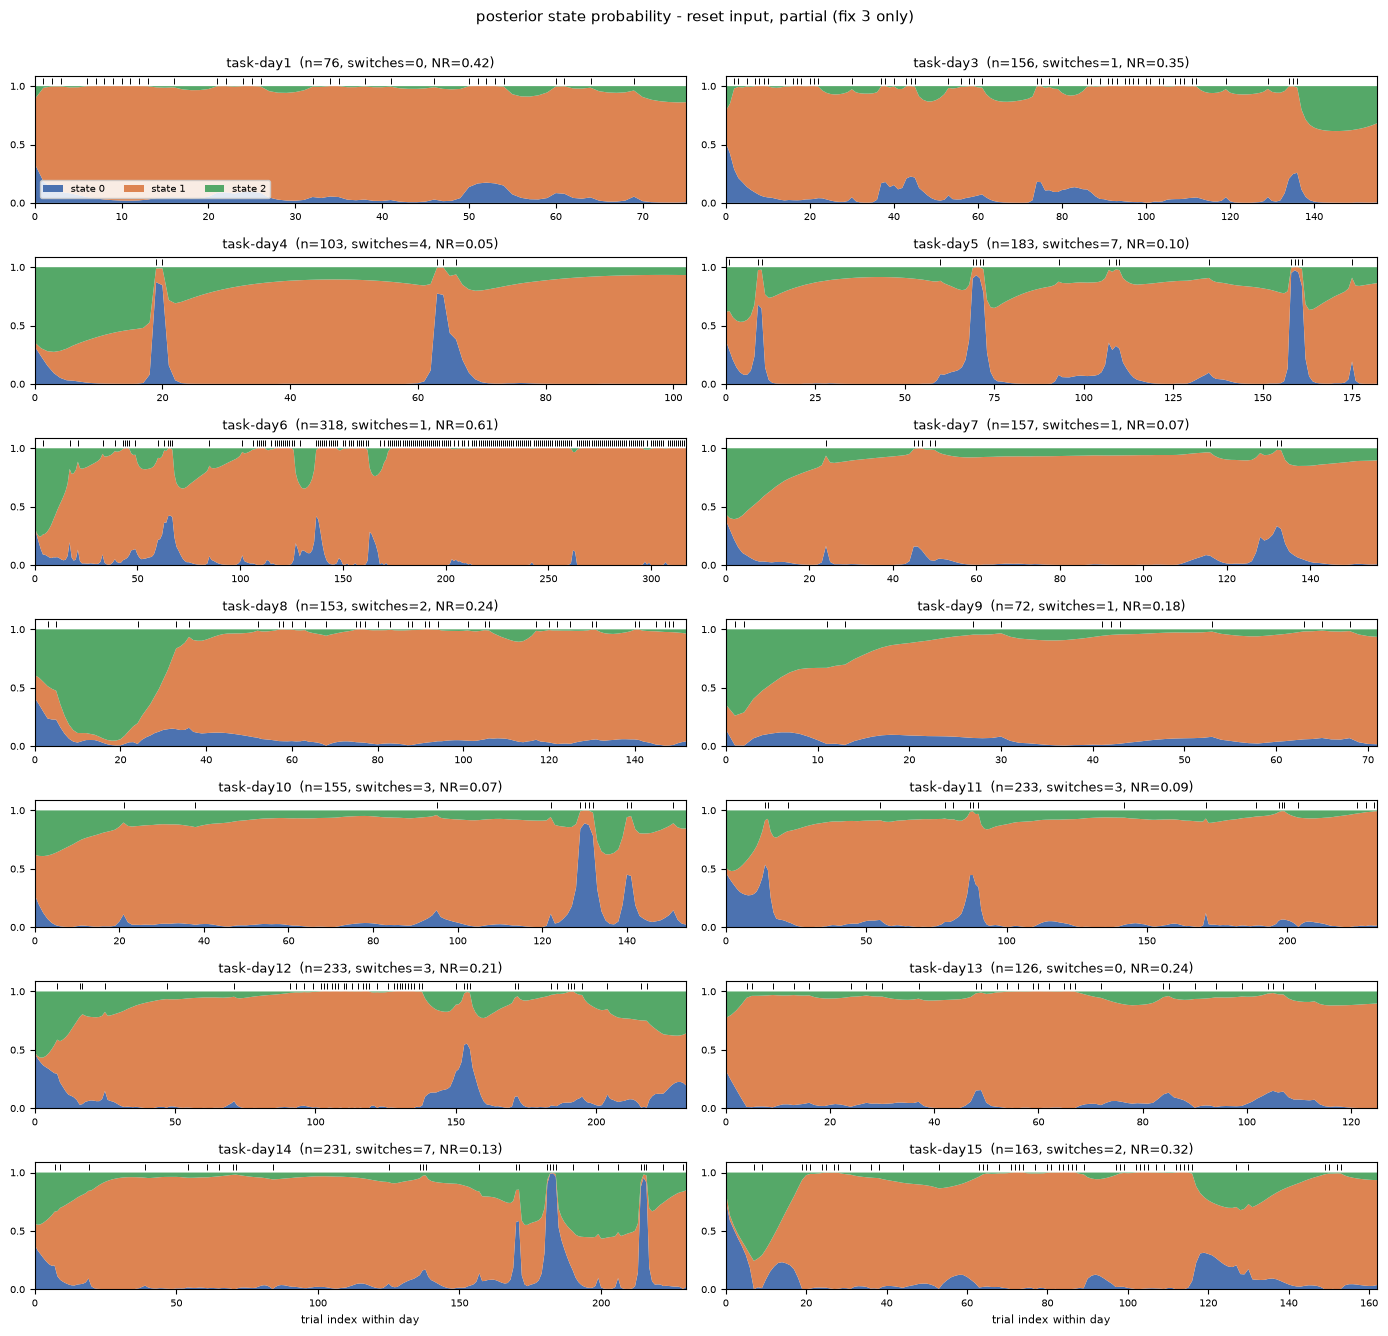

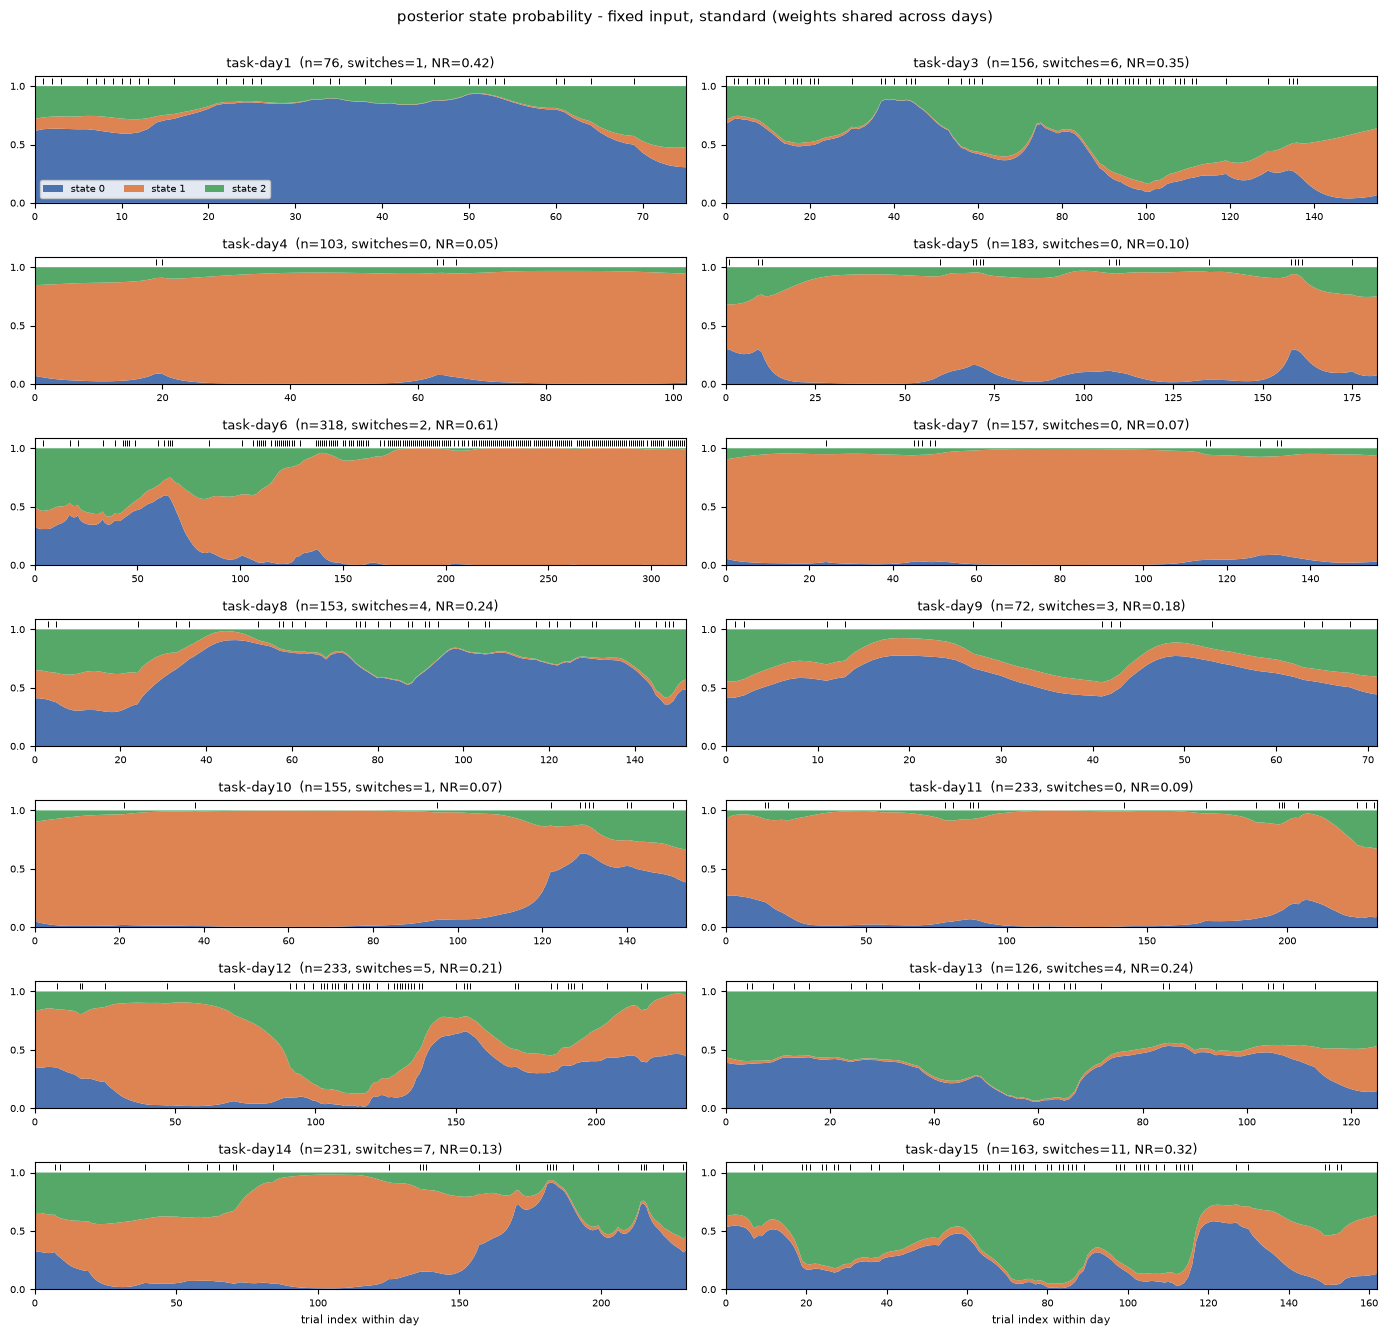

In [17]:
COLORS = ['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3']


def day_panels(tr, sm, title, ncols=2):
    nrows = int(np.ceil(len(DAYS) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.0 * ncols, 1.9 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for i, d in enumerate(DAYS):
        ax = axes[i]
        sl = slice(SESS[i], SESS[i + 1])
        g = sm['gamma'][sl]
        t = np.arange(g.shape[0])
        ax.stackplot(t, *[g[:, k] for k in range(K)],
                     colors=COLORS[:K], labels=[f'state {k}' for k in range(K)])
        nr = np.flatnonzero(tr['yA'].to_numpy()[sl] == 1)
        ax.plot(nr, np.full(len(nr), 1.045), '|', color='k', ms=4, mew=.7)
        ax.set_xlim(0, max(g.shape[0] - 1, 1)); ax.set_ylim(0, 1.09)
        ax.set_yticks([0, .5, 1])
        ax.set_title(f'{d}  (n={g.shape[0]}, switches={sm["switches"][i]}, '
                     f'NR={ (tr["yA"].to_numpy()[sl] == 1).mean():.2f})', fontsize=9)
        if i >= len(DAYS) - ncols:
            ax.set_xlabel('trial index within day', fontsize=8)
        ax.tick_params(labelsize=7)
    for j in range(len(DAYS), len(axes)):
        axes[j].axis('off')
    axes[0].legend(loc='lower left', fontsize=7, ncol=K, framealpha=.85)
    fig.suptitle(title, y=1.001, fontsize=11)
    plt.tight_layout(); plt.show()


day_panels(tr_fixed, sm_par_fix, 'posterior state probability - fixed input, partial (fix 1 + fix 3)')
day_panels(tr_reset, sm_par_res, 'posterior state probability - reset input, partial (fix 3 only)')
day_panels(tr_fixed, sm_std_fix, 'posterior state probability - fixed input, standard (weights shared across days)')

### 5.3 day別の重み軌跡

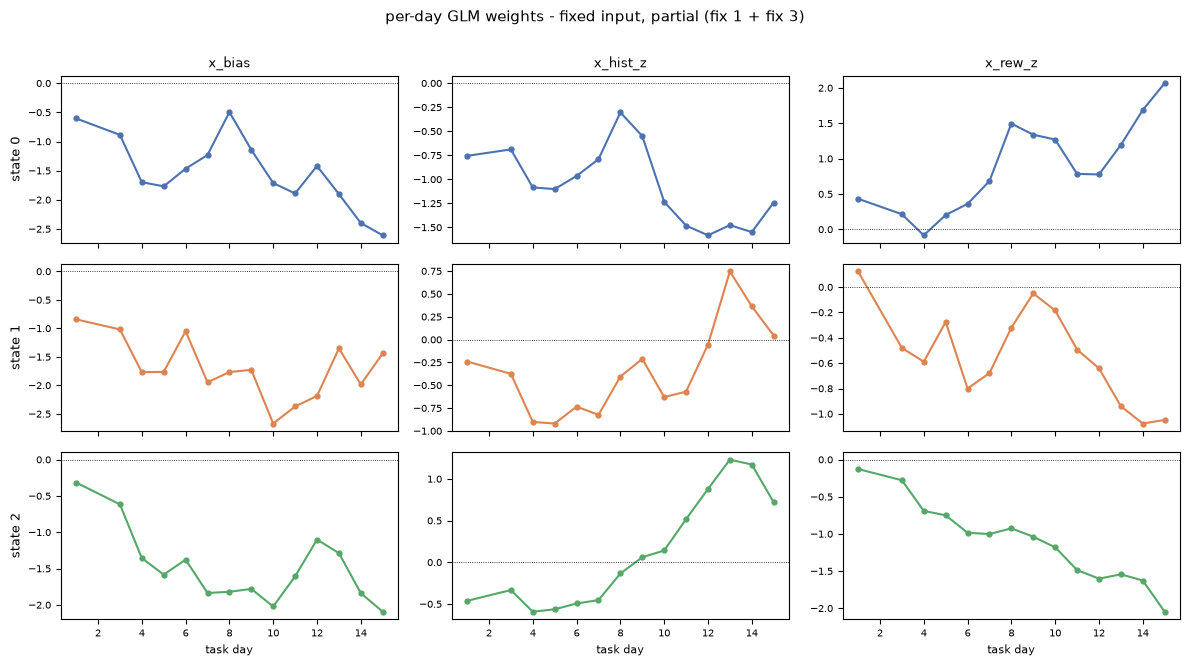

day間の標準偏差（状態でプール）:
  x_bias    0.532   |day間差分| 平均 0.406
  x_hist_z  0.499   |day間差分| 平均 0.252
  x_rew_z   0.494   |day間差分| 平均 0.247


In [18]:
def weight_panels(fit, title):
    w = fit[2][:, :, :, 1]                       # (N, K, D)
    per_day = np.stack([w[SESS[i]] for i in range(len(DAYS))])   # (S, K, D)
    day_num = [int(d.replace('task-day', '')) for d in DAYS]
    fig, axes = plt.subplots(K, D, figsize=(4.0 * D, 2.2 * K), sharex=True)
    for k in range(K):
        for j in range(D):
            ax = axes[k, j]
            ax.plot(day_num, per_day[:, k, j], marker='o', ms=3.5, color=COLORS[k])
            ax.axhline(0, color='k', lw=.6, ls=':')
            if k == 0:
                ax.set_title(INPUT_COLS[j], fontsize=9)
            if j == 0:
                ax.set_ylabel(f'state {k}', fontsize=9)
            if k == K - 1:
                ax.set_xlabel('task day', fontsize=8)
            ax.tick_params(labelsize=7)
    fig.suptitle(title, y=1.002, fontsize=11)
    plt.tight_layout(); plt.show()
    return per_day


pd_fix = weight_panels(fin_fix['par'], 'per-day GLM weights - fixed input, partial (fix 1 + fix 3)')
print('day間の標準偏差（状態でプール）:')
for j, c in enumerate(INPUT_COLS):
    print(f'  {c:9s} {pd_fix[:, :, j].std(axis=0).mean():.3f}'
          f'   |day間差分| 平均 {np.abs(np.diff(pd_fix[:, :, j], axis=0)).mean():.3f}')


## 6. 皮質デコードの試行数

要件6.1節の $P(z)\geq0.8$ と 6.4節の day 内バランシング（状態×試行タイプ）を通した後に何試行残るかを、ノート17と同じ手続きで数える。

In [19]:
def balancing_table(tr, sm, label):
    t2 = tr.copy()
    t2['state'] = sm['z']
    t2['p_max'] = sm['pmax']
    kept = t2[t2['p_max'] >= P_THRESHOLD]
    rows = []
    for d in DAYS:
        g = kept[kept['task_day'] == d]
        ct = pd.crosstab(g['trial_type'], g['state'])
        ct = ct.reindex(index=SOUND_TYPES, columns=range(K), fill_value=0)
        rows.append({'task_day': d, 'n_all': int((t2['task_day'] == d).sum()),
                     'n_kept': len(g), 'min_cell': int(ct.values.min()),
                     'usable_balanced': int((ct.min(axis=1) * K).sum())})
    bt = pd.DataFrame(rows)
    print(f'[{label}] P(z)>={P_THRESHOLD} 残存率 {(t2["p_max"] >= P_THRESHOLD).mean():.3f}')
    print(bt.to_string(index=False))
    print(f'  balanced 使用可能試行: 中央値 {bt["usable_balanced"].median():.0f} / '
          f'全day計 {bt["usable_balanced"].sum()} / min_cell=0 のday '
          f'{int((bt["min_cell"] == 0).sum())}/{len(bt)}\n')
    return bt


bal_fix = balancing_table(tr_fixed, sm_par_fix, 'fixed / partial')
bal_res = balancing_table(tr_reset, sm_par_res, 'reset / partial')
bal_std = balancing_table(tr_fixed, sm_std_fix, 'fixed / standard')

[fixed / partial] P(z)>=0.8 残存率 0.351
  task_day  n_all  n_kept  min_cell  usable_balanced
 task-day1     76      17         0                0
 task-day3    156      35         0                0
 task-day4    103       0         0                0
 task-day5    183       0         0                0
 task-day6    318     169         0                0
 task-day7    157      95         0                0
 task-day8    153      83         0                0
 task-day9     72       0         0                0
task-day10    155      79         0                0
task-day11    233      24         0                0
task-day12    233     110         3               36
task-day13    126      49         0                0
task-day14    231      53         0                0
task-day15    163     113         0                0
  balanced 使用可能試行: 中央値 0 / 全day計 36 / min_cell=0 のday 13/14

[reset / partial] P(z)>=0.8 残存率 0.747
  task_day  n_all  n_kept  min_cell  usable_balanced
 task-day1     

[fixed / standard] P(z)>=0.8 残存率 0.479
  task_day  n_all  n_kept  min_cell  usable_balanced
 task-day1     76      41         0                0
 task-day3    156      16         0                0
 task-day4    103     101         0                0
 task-day5    183     134         0                0
 task-day6    318     192         0                0
 task-day7    157     157         0                0
 task-day8    153      30         0                0
 task-day9     72       0         0                0
task-day10    155     114         0                0
task-day11    233     172         0                0
task-day12    233      55         0                0
task-day13    126      17         0                0
task-day14    231      62         0                0
task-day15    163      40         0                0
  balanced 使用可能試行: 中央値 0 / 全day計 0 / min_cell=0 のday 14/14



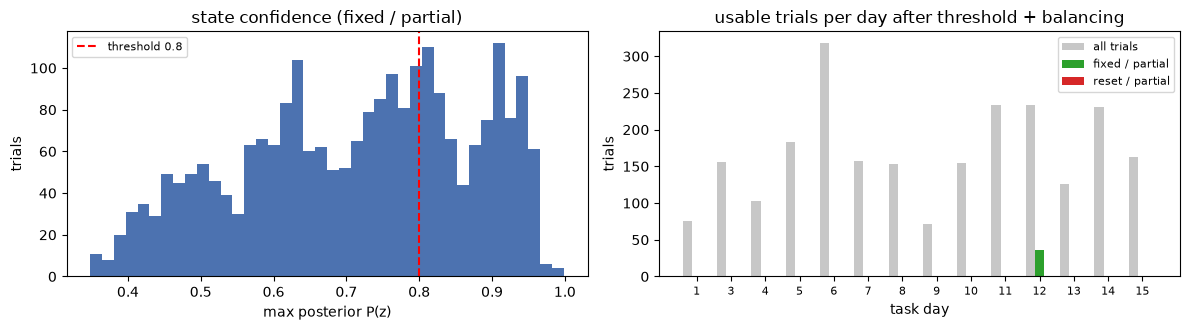

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].hist(sm_par_fix['pmax'], bins=40, color='#4c72b0')
axes[0].axvline(P_THRESHOLD, color='r', ls='--', label=f'threshold {P_THRESHOLD}')
axes[0].set_xlabel('max posterior P(z)'); axes[0].set_ylabel('trials')
axes[0].legend(fontsize=8); axes[0].set_title('state confidence (fixed / partial)')

xi = np.arange(len(DAYS))
day_num = [int(d.replace('task-day', '')) for d in DAYS]
axes[1].bar(xi - .27, bal_fix['n_all'], width=.27, label='all trials', color='#c7c7c7')
axes[1].bar(xi, bal_fix['usable_balanced'], width=.27, label='fixed / partial', color='#2ca02c')
axes[1].bar(xi + .27, bal_res['usable_balanced'], width=.27, label='reset / partial', color='#d62728')
axes[1].set_xticks(xi); axes[1].set_xticklabels(day_num, fontsize=8)
axes[1].set_xlabel('task day'); axes[1].set_ylabel('trials'); axes[1].legend(fontsize=8)
axes[1].set_title('usable trials per day after threshold + balancing')
plt.tight_layout(); plt.show()

## 6.5 状態ごとの試行タイプ

6節のバランシングは、状態のあいだで試行タイプの混合比が違うことへの対処でもある。採用解（fixed 入力、`'partial'`、$\sigma=1$）の最尤状態について、試行タイプの構成を全試行のベースレートと比べる。

観測は Bernoulli なので、Success と Short Pull はどちらも「押下あり」である。この2タイプの差は状態が直接分けた量ではない。入力を平均（Bias $=1$、History の z-score $=0$）に固定したときの $P(\text{No Reaction})$ も並記する。

$P(z)\geq0.8$ の試行に限って、**その日に両方いる状態対だけ**を試行タイプ内で釣り合わせた試行数も出す。6節は 3状態×3タイプのセルが1つでも0だとその日を丸ごと0にする。こちらは欠けた状態を、その対比だけの欠測にする。

In [22]:
def composition(tr, z, pmax, mask):
    '''最尤状態ごとの試行タイプ内訳。mask は tr と同長のブール配列。'''
    t = tr[['task_day', 'trial_type']].copy()
    t['state'] = z
    t['p_max'] = pmax
    if mask is not None:
        t = t.loc[mask]
    ct = (pd.crosstab(t['state'], t['trial_type'])
            .reindex(index=range(K), columns=SOUND_TYPES, fill_value=0))
    frac = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0)
    return t, ct, frac


def show_comp(title, ct, frac):
    out = ct.copy()
    out['n'] = ct.sum(axis=1)
    print(f'[{title}]')
    print(out.to_string())
    print(frac.round(3).to_string())
    print()


base_ct = tr_fixed['trial_type'].value_counts().reindex(SOUND_TYPES)
base_frac = base_ct / base_ct.sum()
print('[ベースレート]  n={}'.format(int(base_ct.sum())))
print(pd.DataFrame({'n': base_ct, 'frac': base_frac.round(3)}).T.to_string())
print()

t_all, ct_all, fr_all = composition(
    tr_fixed, sm_par_fix['z'], sm_par_fix['pmax'], None)
t_hi, ct_hi, fr_hi = composition(
    tr_fixed, sm_par_fix['z'], sm_par_fix['pmax'],
    sm_par_fix['pmax'] >= P_THRESHOLD)
show_comp('最尤状態・全試行', ct_all, fr_all)
show_comp(f'最尤状態・P(z)>={P_THRESHOLD}', ct_hi, fr_hi)

# 入力平均での emission。y=1 が No Reaction、自由重みは w[:,:,:,1]。
w_free = fin_fix['par'][2][:, :, :, 1]
print('入力平均 (Bias=1, History z=0) での状態別確率。重みは day ごとの平均')
for k in range(K):
    rows = np.vstack([w_free[SESS[i], k] for i in range(len(DAYS))])
    p_nr = 1 / (1 + np.exp(-rows[:, 0]))
    print(f'  state {k}: bias {rows[:, 0].mean():+.3f}  hist {rows[:, 1].mean():+.3f}  '
          f'rew {rows[:, 2].mean():+.3f}   P(NR) {p_nr.mean():.3f}  P(押下) {(1 - p_nr).mean():.3f}')
print()


def pair_detail(a, b):
    detail = []
    for d in DAYS:
        g = t_hi[t_hi['task_day'] == d]
        ct = (pd.crosstab(g['trial_type'], g['state'])
                .reindex(index=SOUND_TYPES, columns=[a, b], fill_value=0))
        if (ct.sum(axis=0) == 0).any():
            detail.append(0)
        else:
            detail.append(int((ct.min(axis=1) * 2).sum()))
    return detail


pair_usable = {(a, b): pair_detail(a, b) for a, b in [(0, 1), (0, 2), (1, 2)]}
print(f'P(z)>={P_THRESHOLD} のあと、両方いる日だけを試行タイプ内で釣り合わせた試行数')
for (a, b), detail in pair_usable.items():
    nd = int(np.sum(np.array(detail) > 0))
    print(f'  state {a} vs {b}: {nd}/{len(DAYS)} day  合計 {sum(detail)}  日別 {detail}')

hi_mat = np.zeros((len(DAYS), K), dtype=int)
for i, d in enumerate(DAYS):
    g = t_hi[t_hi['task_day'] == d]
    for k in range(K):
        hi_mat[i, k] = int((g['state'] == k).sum())


[ベースレート]  n=2359
trial_type   Success  Short Pull  No Reaction
n           1293.000     511.000      555.000
frac           0.548       0.217        0.235

[最尤状態・全試行]
trial_type  Success  Short Pull  No Reaction     n
state                                             
0               255          87          111   453
1              1006         399          398  1803
2                32          25           46   103
trial_type  Success  Short Pull  No Reaction
state                                       
0             0.563       0.192        0.245
1             0.558       0.221        0.221
2             0.311       0.243        0.447

[最尤状態・P(z)>=0.8]
trial_type  Success  Short Pull  No Reaction    n
state                                            
0                83          37           59  179
1               280         121          220  621
2                 5           6           16   27
trial_type  Success  Short Pull  No Reaction
state                                   

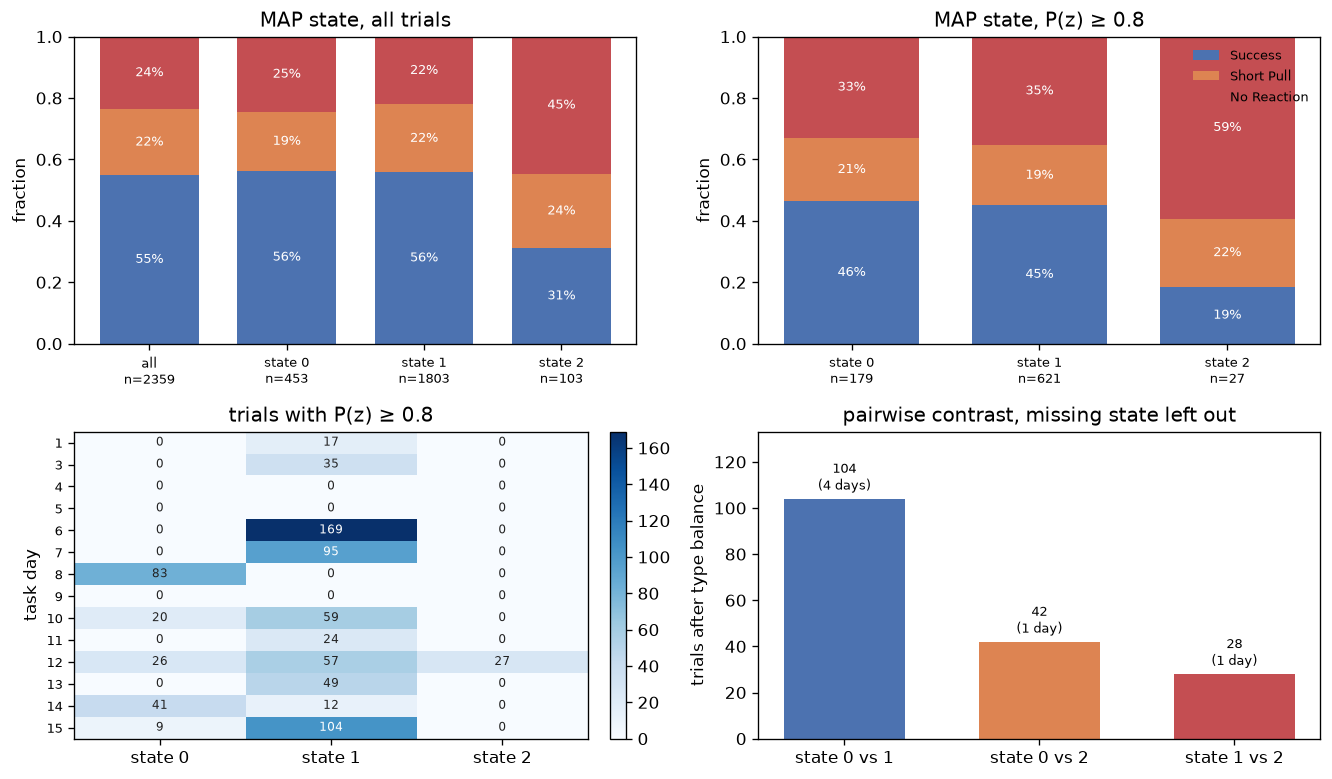

In [23]:
TYPE_COLORS = {'Success': '#4c72b0', 'Short Pull': '#dd8452', 'No Reaction': '#c44e52'}
day_num = [int(d.replace('task-day', '')) for d in DAYS]


def stacked(ax, fracs, counts, title):
    '''fracs: 行がカテゴリ（全体 + state）、列が SOUND_TYPES。counts は各行の n。'''
    x = np.arange(len(fracs))
    bottom = np.zeros(len(fracs))
    for col in SOUND_TYPES:
        h = fracs[col].to_numpy(dtype=float)
        ax.bar(x, h, bottom=bottom, color=TYPE_COLORS[col], width=0.72, label=col)
        for i, (yi, hi) in enumerate(zip(bottom, h)):
            if hi >= 0.08:
                ax.text(i, yi + hi / 2, f'{hi:.0%}', ha='center', va='center',
                        color='white', fontsize=8)
        bottom += h
    ax.set_xticks(x)
    ax.set_xticklabels([f'{name}\nn={n}' for name, n in zip(fracs.index, counts)], fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel('fraction')
    ax.set_title(title)


base_row = base_frac.to_frame().T
base_row.index = ['all']
frac_map = pd.concat([base_row, fr_all])
frac_map.index = ['all', 'state 0', 'state 1', 'state 2']
n_map = [int(base_ct.sum())] + [int(ct_all.loc[k].sum()) for k in range(K)]
n_hi = [int(ct_hi.loc[k].sum()) for k in range(K)]
frac_thr = fr_hi.copy()
frac_thr.index = ['state 0', 'state 1', 'state 2']

fig, axes = plt.subplots(2, 2, figsize=(11.2, 6.6))
stacked(axes[0, 0], frac_map, n_map, 'MAP state, all trials')
stacked(axes[0, 1], frac_thr, n_hi, f'MAP state, P(z) ≥ {P_THRESHOLD}')
axes[0, 1].legend(fontsize=8, loc='upper right', frameon=False)

im = axes[1, 0].imshow(hi_mat, aspect='auto', cmap='Blues')
axes[1, 0].set_xticks(range(K))
axes[1, 0].set_xticklabels([f'state {k}' for k in range(K)])
axes[1, 0].set_yticks(range(len(DAYS)))
axes[1, 0].set_yticklabels(day_num, fontsize=8)
axes[1, 0].set_ylabel('task day')
axes[1, 0].set_title(f'trials with P(z) ≥ {P_THRESHOLD}')
for i in range(hi_mat.shape[0]):
    for k in range(K):
        val = hi_mat[i, k]
        axes[1, 0].text(k, i, str(val), ha='center', va='center', fontsize=7,
                        color='white' if val > hi_mat.max() * 0.55 else '#222')
fig.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

pairs = [(0, 1), (0, 2), (1, 2)]
usable = [sum(pair_usable[p]) for p in pairs]
ndays = [int(np.sum(np.array(pair_usable[p]) > 0)) for p in pairs]
x = np.arange(len(pairs))
axes[1, 1].bar(x, usable, color=['#4c72b0', '#dd8452', '#c44e52'], width=0.62)
for i, (u, nd) in enumerate(zip(usable, ndays)):
    axes[1, 1].text(i, u + 2, f'{u}\n({nd} day{"s" if nd != 1 else ""})',
                    ha='center', va='bottom', fontsize=8)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels([f'state {a} vs {b}' for a, b in pairs])
axes[1, 1].set_ylabel('trials after type balance')
axes[1, 1].set_ylim(0, max(usable) * 1.28 if usable else 1)
axes[1, 1].set_title('pairwise contrast, missing state left out')
plt.tight_layout()
plt.show()


## 7. まとめ

In [21]:
print('=' * 78)
print(f'Ver.5 Dynamic GLM-HMM / 著者実装  mouse={MOUSE_ID}  days={len(DAYS)}  試行={N}  K={K}')
print('=' * 78)
print('[修正1] History の day 頭リセット')
d_res = (tr_reset.loc[tr_reset['k'] < 10, 'x_hist_z'].mean()
         - tr_reset.loc[tr_reset['k'] >= 10, 'x_hist_z'].mean())
d_fix = (tr_fixed.loc[tr_fixed['k'] < 10, 'x_hist_z'].mean()
         - tr_fixed.loc[tr_fixed['k'] >= 10, 'x_hist_z'].mean())
print(f'    冒頭10試行のズレ (x_hist_z): reset {d_res:+.3f} -> fixed {d_fix:+.3f}')
print(f'    k=0 の値: reset {tr_reset[tr_reset["k"] == 0]["x_hist_z"].mean():+.2f} -> '
      f'fixed {tr_fixed[tr_fixed["k"] == 0]["x_hist_z"].mean():+.2f}')

print()
print('[修正3] sigma の選択（held-out LL/試行、5-fold）')
for name, t in [('reset', cv_res), ('fixed', cv_fix)]:
    b = t.loc[t['test_ll'].idxmax()]
    print(f'    {name:6s} standard {t.iloc[0]["test_ll"]:+.4f} -> '
          f'最良 sigma={b["sigma"]:<8g} {b["test_ll"]:+.4f}'
          f'   {"(グリッド上端)" if b["sigma"] == SIGMA_GRID[-1] else ""}')
print(f'    列別 sigma (bias座標のみ, fixed): 最良 bias={sig2d["sigma_bias"]:g}  '
      f'{sig2d["table"]["test_ll"].max():+.4f}  '
      f'(掃引幅 {sig2d["table"]["test_ll"].max() - sig2d["table"]["test_ll"].min():.4f} '
      f'< SE {sig2d["table"]["se"].mean():.4f} なので採用せず)')
print(f'    最終フィットの sigma = {SIGMA_FINAL:g}（全列共通）')

def n90(sm):
    return f"{int((sm['dom'] >= 0.9).sum())}/{len(DAYS)}"


print()
print('[状態構造] ノート17（自前実装・reset入力・alpha=100）との比較')
hdr = f'    {"":26s} {"switch計":>9s} {"90%day":>8s} {"run中央":>8s} {"残存率":>7s} {"balanced計":>10s}'
print(hdr)
print(f'    {"note17 dynamic":26s} {28:9d} {"0/14":>8s} {48:8d} {0.723:7.3f} {372:10d}')
for lbl, sm, bt in [('fixed / standard', sm_std_fix, bal_std),
                    ('reset / partial', sm_par_res, bal_res),
                    ('fixed / partial', sm_par_fix, bal_fix)]:
    print(f'    {lbl:26s} {sm["switches"].sum():9d} '
          f'{n90(sm):>8s} '
          f'{int(np.median(sm["runs"])):8d} {(sm["pmax"] >= P_THRESHOLD).mean():7.3f} '
          f'{bt["usable_balanced"].sum():10d}')

print()
print('[状態は day 内の時刻に張り付いているか] 状態別の day 内正規化位置（平均±sd）')
for lbl, sm in [('reset / partial', sm_par_res), ('fixed / partial', sm_par_fix)]:
    parts = []
    for k in range(K):
        rel = np.concatenate([np.linspace(0, 1, SESS[i + 1] - SESS[i])[
            sm['z'][SESS[i]:SESS[i + 1]] == k] for i in range(len(DAYS))])
        parts.append(f's{k} {rel.mean():.2f}±{rel.std():.2f}' if len(rel) else f's{k} n/a')
    print(f'    {lbl:20s} ' + '  '.join(parts))
print('=' * 78)

Ver.5 Dynamic GLM-HMM / 著者実装  mouse=VG1GC-66  days=14  試行=2359  K=3
[修正1] History の day 頭リセット
    冒頭10試行のズレ (x_hist_z): reset -0.565 -> fixed +0.149
    k=0 の値: reset -2.49 -> fixed -0.02

[修正3] sigma の選択（held-out LL/試行、5-fold）
    reset  standard -0.4350 -> 最良 sigma=1        -0.4225   
    fixed  standard -0.4258 -> 最良 sigma=1        -0.4201   
    列別 sigma (bias座標のみ, fixed): 最良 bias=0.1  -0.4216  (掃引幅 0.0058 < SE 0.0058 なので採用せず)
    最終フィットの sigma = 1（全列共通）

[状態構造] ノート17（自前実装・reset入力・alpha=100）との比較
                                 switch計   90%day    run中央     残存率  balanced計
    note17 dynamic                    28     0/14       48   0.723        372
    fixed / standard                  44     6/14       17   0.479          0
    reset / partial                   35    11/14       12   0.747          0
    fixed / partial                   29     6/14       32   0.351         36

[状態は day 内の時刻に張り付いているか] 状態別の day 内正規化位置（平均±sd）
    reset / partial      s0 0.54±0.35  s1 0.52±0.28  s2 0